# Analyse Exploratoire - Catastrophes Naturelles en France

**Objectif** : Analyser l'évolution des catastrophes naturelles en France et identifier les zones et types de risques les plus critiques  
**Date** : 2026-02-18  
**Auteur** : DA_jab  
**Données** : 
- `dev.duckdb` : Base GASPAR (catastrophes naturelles françaises)
- `odis.duckdb` : Données socio-démographiques (non utilisé dans cette version pour performances)

**Type d'analyse** : Analyse Exploratoire de Données (EDA)

**Contexte** :  
Cette analyse vise à comprendre l'évolution temporelle, la répartition géographique et les types de catastrophes naturelles recensées en France depuis l'an 2000.

---
## 1. Imports et Configuration

In [15]:
# ==========================================
# IMPORTS ET CONFIGURATION
# ==========================================

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

# Configuration d'affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.precision", 2)

# Configuration matplotlib pour des graphiques professionnels
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✅ Imports réussis !")
print(f"📦 Pandas version: {pd.__version__}")
print(f"🦆 DuckDB version: {duckdb.__version__}")

✅ Imports réussis !
📦 Pandas version: 3.0.0
🦆 DuckDB version: 1.4.4


---
## 2. Connexion à la Base de Données

In [ ]:
# ==========================================
# CONNEXION À LA BASE DE DONNÉES
# ==========================================

# Connexion en lecture seule pour éviter les modifications accidentelles
con = duckdb.connect(database="dev.duckdb", read_only=True)

print("✅ Connexion établie à dev.duckdb")
print("📁 Mode : Lecture seule (read_only=True)")

# ⚠️ IMPORTANT : odis.duckdb fait 2 Go et prend 30-60s à charger
# Tentative d'attachement d'odis.duckdb pour analyses avancées
try:
    print("\n🔄 Chargement de odis.duckdb... (30-60 secondes)")
    con.sql("ATTACH 'odis.duckdb' AS odis;")
    print("✅ odis.duckdb attaché avec succès")
    print("💡 Analyses population disponibles dans section 8.2")
except Exception as e:
    print(f"⚠️  odis.duckdb non disponible : {str(e)}")
    print("💡 Certaines analyses avancées seront désactivées")

✅ Connexion établie à dev.duckdb
📁 Mode : Lecture seule (read_only=True)


---
## 3. Exploration Initiale - Découverte du Schéma

### 3.1 Liste des Tables Disponibles

In [3]:
# Lister toutes les tables disponibles
tables = con.sql("SHOW TABLES").df()
print(f"📊 Nombre de tables disponibles : {len(tables)}")
print("\nTables :")
tables

📊 Nombre de tables disponibles : 13

Tables :


,name
0,azi_gaspar
1,catnat_gaspar
2,ccr_details
3,ccr_main_page
4,dicrim_gaspar
5,my_first_dbt_model
6,my_second_dbt_model
7,pprm_gaspar
8,pprn_gaspar
9,pprt_gaspar


### 3.2 Schéma de la Table Principale

🔑 **ÉTAPE CRITIQUE** : Toujours vérifier le schéma avant d'écrire des requêtes SQL !  
Cela évite les erreurs `BinderException: Referenced column not found`

In [4]:
# Description complète du schéma de catnat_gaspar
schema_catnat = con.sql("DESCRIBE catnat_gaspar").df()
print("📋 Schéma de la table catnat_gaspar :")
print(f"Nombre de colonnes : {len(schema_catnat)}\n")
schema_catnat

📋 Schéma de la table catnat_gaspar :
Nombre de colonnes : 10



,column_name,column_type,null,key,default,extra
0,cod_nat_catnat,VARCHAR,YES,None,None,None
1,cod_commune,VARCHAR,YES,None,None,None
2,lib_commune,VARCHAR,YES,None,None,None
3,num_risque_jo,VARCHAR,YES,None,None,None
4,lib_risque_jo,VARCHAR,YES,None,None,None
5,dat_deb,VARCHAR,YES,None,None,None
6,dat_fin,VARCHAR,YES,None,None,None
7,dat_pub_arrete,VARCHAR,YES,None,None,None
8,dat_pub_jo,VARCHAR,YES,None,None,None
9,dat_maj,VARCHAR,YES,None,None,None


**📝 Notes importantes sur les noms de colonnes :**

Les vrais noms dans la base sont abrégés :
- `dat_pub_jo` : Date de publication au Journal Officiel (**VARCHAR**, pas DATE !)
- `cod_commune` : Code INSEE de la commune
- `lib_commune` : Nom de la commune
- `lib_risque_jo` : Type de risque
- `dat_deb`, `dat_fin` : Dates de début et fin

⚠️ **Les dates sont en VARCHAR** → Il faudra les convertir avec `CAST(col AS DATE)`

### 3.3 Aperçu des Données

In [5]:
# Aperçu des 5 premières lignes
apercu = con.sql("SELECT * FROM catnat_gaspar LIMIT 5").df()
print("👀 Aperçu des 5 premières lignes :")
apercu

👀 Aperçu des 5 premières lignes :


,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
0,BUDD8750027A,06120,Saint-Étienne-de-Tinée,GLT,Glissement de Terrain,1985-01-01,1986-12-31,1987-05-20,1987-05-24,2022-05-20 15:53:47.090
1,BUDD8750038A,2B050,Calvi,ICB,Inondations et/ou Coulées de Boue,1987-01-14,1987-01-15,1987-06-24,1987-07-10,2022-05-20 15:53:47.111
2,BUDD8750038A,30006,Aimargues,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
3,BUDD8750038A,30020,Aubord,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
4,BUDD8750038A,30033,Beauvoisin,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138


In [6]:
# Statistiques de base
stats_base = con.sql("""
    SELECT 
        COUNT(*) as total_enregistrements,
        COUNT(DISTINCT cod_commune) as communes_uniques,
        COUNT(DISTINCT lib_risque_jo) as types_risques_uniques,
        MIN(dat_pub_jo) as premiere_date_pub,
        MAX(dat_pub_jo) as derniere_date_pub
    FROM catnat_gaspar
""").df()

print("📊 Statistiques Globales :")
print("=" * 60)
for col in stats_base.columns:
    print(f"{col:30} : {stats_base[col].iloc[0]}")
print("=" * 60)

📊 Statistiques Globales :
total_enregistrements          : 260799
communes_uniques               : 34704
types_risques_uniques          : 21
premiere_date_pub              : 1982-09-30 00:00:00
derniere_date_pub              : 2025-10-23 02:00:00


---
## 4. Analyse Temporelle

### 4.1 Évolution Annuelle des Catastrophes (depuis 2000)

In [17]:
# ==========================================
# ANALYSE TEMPORELLE : ÉVOLUTION ANNUELLE
# ==========================================

# ⚠️ IMPORTANT : Utiliser CAST(dat_pub_jo AS DATE) car la colonne est en VARCHAR
evolution = con.sql("""
    SELECT 
        YEAR(CAST(dat_pub_jo AS DATE)) as annee,
        COUNT(*) as nb_catastrophes
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2000-01-01'
    GROUP BY YEAR(CAST(dat_pub_jo AS DATE))
    ORDER BY annee
""").df()

print(f"📈 Données disponibles de {evolution['annee'].min()} à {evolution['annee'].max()}")
print(f"📊 Total des catastrophes : {evolution['nb_catastrophes'].sum():,}")
print(f"📉 Moyenne annuelle : {evolution['nb_catastrophes'].mean():.1f}")
print("\nDernières années :")
evolution.tail(10)

📈 Données disponibles de 2000 à 2025
📊 Total des catastrophes : 98,654
📉 Moyenne annuelle : 3794.4

Dernières années :


,annee,nb_catastrophes
16,2016,3237
17,2017,1633
18,2018,6493
19,2019,5173
20,2020,5240
21,2021,5098
22,2022,1457
23,2023,9379
24,2024,5379
25,2025,1301


### 4.2 Visualisation de la Tendance

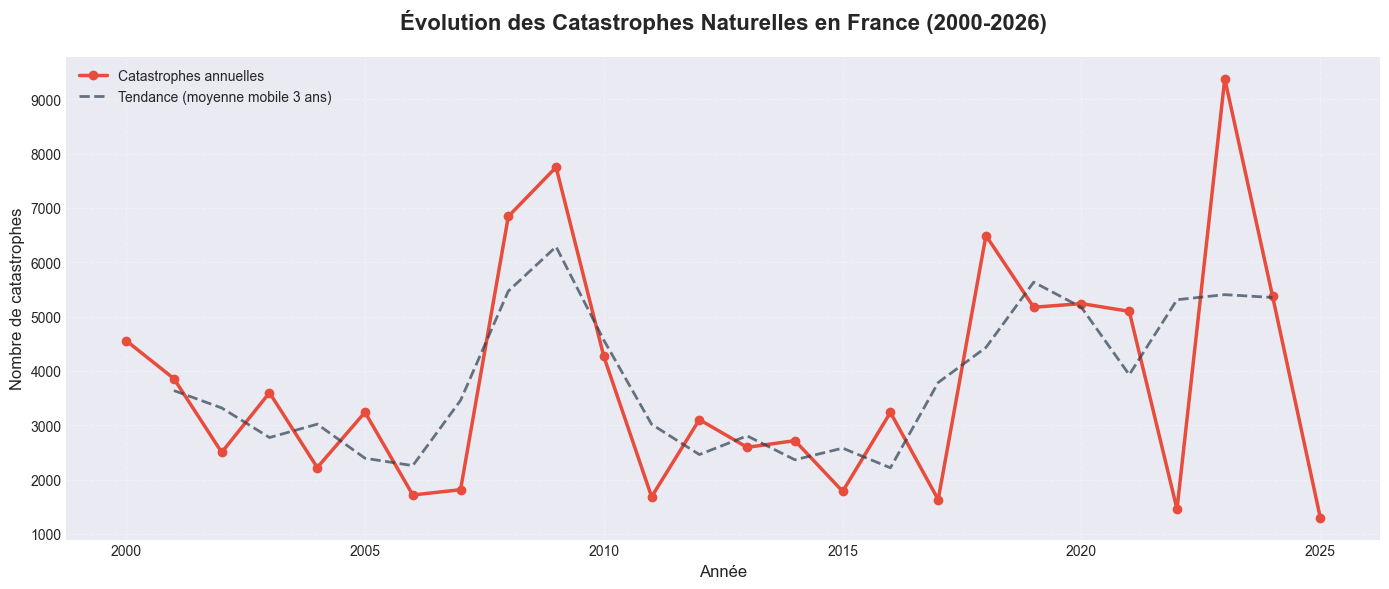


🔥 Année record : 2023 avec 9379 catastrophes


In [18]:
# Graphique de l'évolution temporelle
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    evolution['annee'], 
    evolution['nb_catastrophes'], 
    marker='o', 
    linewidth=2.5, 
    color='#e74c3c',
    markersize=6,
    label='Catastrophes annuelles'
)

# Ligne de tendance (moyenne mobile sur 3 ans)
evolution['moyenne_mobile'] = evolution['nb_catastrophes'].rolling(window=3, center=True).mean()
ax.plot(
    evolution['annee'], 
    evolution['moyenne_mobile'], 
    linestyle='--', 
    linewidth=2, 
    color='#2c3e50',
    alpha=0.7,
    label='Tendance (moyenne mobile 3 ans)'
)

ax.set_title(
    'Évolution des Catastrophes Naturelles en France (2000-2026)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Nombre de catastrophes', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Insights
annee_max = evolution.loc[evolution['nb_catastrophes'].idxmax()]
print(f"\n🔥 Année record : {int(annee_max['annee'])} avec {int(annee_max['nb_catastrophes'])} catastrophes")

---
## 5. Analyse par Type de Risque

### 5.1 Top 10 des Types de Risques (depuis 2010)

In [19]:
# ==========================================
# ANALYSE PAR TYPE DE RISQUE
# ==========================================

types_risques = con.sql("""
    SELECT 
        lib_risque_jo,
        COUNT(*) as occurrences,
        COUNT(DISTINCT cod_commune) as communes_touchees,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pourcentage
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2010-01-01'
    GROUP BY lib_risque_jo
    ORDER BY occurrences DESC
    LIMIT 10
""").df()

print("🎯 Top 10 des types de risques les plus fréquents (depuis 2010) :\n")
types_risques

🎯 Top 10 des types de risques les plus fréquents (depuis 2010) :



,lib_risque_jo,occurrences,communes_touchees,pourcentage
0,Inondations et/ou Coulées de Boue,28663,15743,47.34
1,Sécheresse,26662,12709,44.04
2,Mouvement de Terrain,3108,2466,5.13
3,Chocs Mécaniques liés à l'action des Vagues,1394,1098,2.30
4,Inondations Remontée Nappe,541,476,0.89
5,Secousse Sismique,99,99,0.16
6,Vents Cycloniques,44,44,0.07
7,Avalanche,31,24,0.05
8,Lave Torrentielle,2,2,0.00


### 5.2 Visualisation des Types de Risques

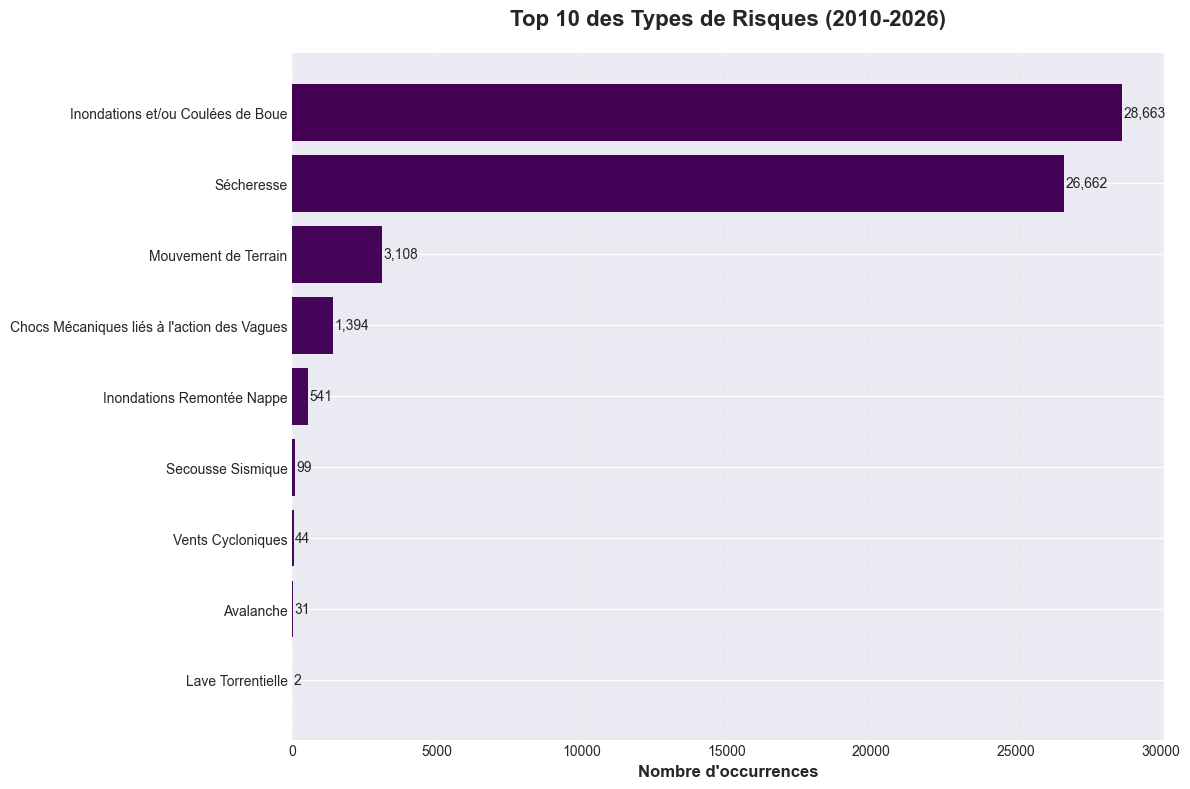


💡 Le risque le plus fréquent représente 47.3% du total


In [10]:
# Graphique en barres horizontales
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(range(len(types_risques)))
ax.barh(
    types_risques['lib_risque_jo'], 
    types_risques['occurrences'], 
    color=colors
)

ax.set_xlabel('Nombre d\'occurrences', fontsize=12, fontweight='bold')
ax.set_title(
    'Top 10 des Types de Risques (2010-2026)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Ajouter les valeurs sur les barres
for i, (idx, row) in enumerate(types_risques.iterrows()):
    ax.text(
        row['occurrences'] + 50, 
        i, 
        f"{int(row['occurrences']):,}", 
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Insights
print(f"\n💡 Le risque le plus fréquent représente {types_risques.iloc[0]['pourcentage']:.1f}% du total")

---
## 6. Analyse Géographique

### 6.1 Top 15 des Communes les Plus Touchées (depuis 2015)

In [20]:
# ==========================================
# ANALYSE GÉOGRAPHIQUE
# ==========================================

top_communes = con.sql("""
    SELECT 
        lib_commune,
        cod_commune,
        COUNT(*) as nb_catastrophes,
        COUNT(DISTINCT lib_risque_jo) as nb_types_risques,
        MIN(CAST(dat_pub_jo AS DATE)) as premiere_catastrophe,
        MAX(CAST(dat_pub_jo AS DATE)) as derniere_catastrophe
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2015-01-01'
    GROUP BY lib_commune, cod_commune
    ORDER BY nb_catastrophes DESC
    LIMIT 15
""").df()

print("🏘️ Top 15 des communes les plus touchées (depuis 2015) :\n")
top_communes

🏘️ Top 15 des communes les plus touchées (depuis 2015) :



,lib_commune,cod_commune,nb_catastrophes,nb_types_risques,premiere_catastrophe,derniere_catastrophe
0,La Verdière,83146,32,2,2018-10-20,2024-08-02
1,Nice,06088,31,4,2015-01-06,2024-12-02
2,Cagnes-sur-Mer,06027,20,4,2015-01-06,2024-10-18
3,Vence,06157,19,3,2015-02-19,2024-12-20
4,Saint-Louis,97414,19,3,2018-02-01,2024-06-28
5,La Trinité,06149,18,3,2015-03-04,2024-12-20
6,Colomars,06046,17,3,2015-02-19,2025-09-25
7,Saint-Jeannet,06122,17,3,2015-02-19,2024-12-02
8,Dole,39198,16,2,2018-10-20,2024-09-27
9,Dasle,25196,16,1,2020-11-14,2020-11-14


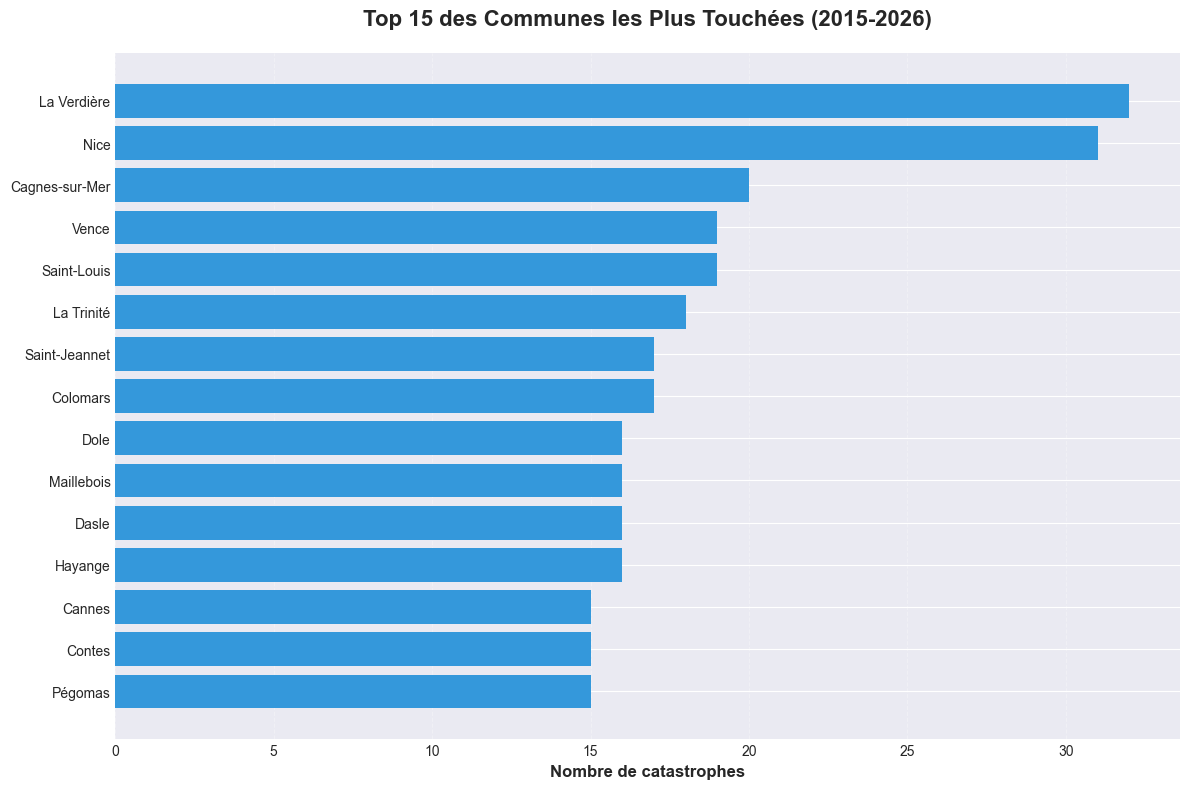

In [12]:
# Graphique des communes
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    top_communes['lib_commune'], 
    top_communes['nb_catastrophes'], 
    color='#3498db'
)

ax.set_xlabel('Nombre de catastrophes', fontsize=12, fontweight='bold')
ax.set_title(
    'Top 15 des Communes les Plus Touchées (2015-2026)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

---
## 7. Statistiques Globales et Synthèse

In [13]:
# ==========================================
# STATISTIQUES GLOBALES FINALES
# ==========================================

stats_finales = con.sql("""
    SELECT 
        COUNT(*) as total_catastrophes,
        COUNT(DISTINCT cod_commune) as communes_touchees,
        COUNT(DISTINCT lib_risque_jo) as types_risques_differents,
        MIN(dat_pub_jo) as premiere_catastrophe,
        MAX(dat_pub_jo) as derniere_catastrophe
    FROM catnat_gaspar
""").df()

print("\n" + "=" * 70)
print("📊 STATISTIQUES GLOBALES - BASE COMPLÈTE")
print("=" * 70)
for col in stats_finales.columns:
    print(f"{col:35} : {stats_finales[col].iloc[0]}")
print("=" * 70)

# Ratio communes touchées / communes françaises
nb_communes_france = 35000  # Approximation
taux_couverture = (stats_finales['communes_touchees'].iloc[0] / nb_communes_france) * 100
print(f"\n💡 Environ {taux_couverture:.1f}% des communes françaises ont été touchées")


📊 STATISTIQUES GLOBALES - BASE COMPLÈTE
total_catastrophes                  : 260799
communes_touchees                   : 34704
types_risques_differents            : 21
premiere_catastrophe                : 1982-09-30 00:00:00
derniere_catastrophe                : 2025-10-23 02:00:00

💡 Environ 99.2% des communes françaises ont été touchées


---
## 8. Conclusions et Insights

### 📊 Principaux Enseignements

1. **Tendance temporelle** : 
   - **98,654 catastrophes** recensées entre 2000 et 2025 (moyenne : 3,794/an)
   - **Année record : 2023** avec 9,379 catastrophes naturelles déclarées
   - **Forte volatilité** avec des pics notables en 2008 (~7,700), 2018 (~6,500) et 2023 (~9,400)
   - **Tendance à la hausse** depuis 2017, suggérant une intensification des phénomènes climatiques
   
2. **Types de risques dominants** :
   - **Inondations et Coulées de Boue** : 28,663 occurrences (47.34%) - risque majeur
   - **Sécheresse** : 26,662 occurrences (44.04%) - problème croissant lié au climat
   - Ces **deux types représentent 91%** du total des catastrophes (depuis 2010)
   - **Mouvements de Terrain** : 3,108 occurrences (5.13%) - troisième risque
   - Les autres risques (chocs mécaniques, séismes, cyclones) restent marginaux (<3%)
   
3. **Zones géographiques critiques** :
   - **Alpes-Maritimes particulièrement touchées** : Nice (31), Cagnes-sur-Mer (20), Vence (19)
   - **La Verdière (Var)** : commune la plus touchée avec 32 catastrophes depuis 2015
   - **Diversité géographique** : DOM-TOM (Saint-Louis), Jura (Dole), Moselle (Hayange)
   - Les zones côtières et montagneuses sont sur-représentées

### 🎯 Analyses Complémentaires à Suivre

Les sections suivantes approfondissent l'analyse avec :
- **Saisonnalité** : Identification des mois à risque
- **Exposition population** : Croisement avec données démographiques
- **Impact économique** : Analyse des indemnisations CCR
- **Corrélations régionales** : Liens entre zones géographiques et types de risques

---
## 8bis. Analyses Avancées

### 8.1 Analyse de Saisonnalité - Détection des Périodes à Risque

In [21]:
# ==========================================
# ANALYSE SAISONNALITÉ : MOIS PAR MOIS
# ==========================================

saisonnalite = con.sql("""
    SELECT 
        MONTH(CAST(dat_deb AS DATE)) as mois,
        CASE MONTH(CAST(dat_deb AS DATE))
            WHEN 1 THEN 'Janvier'
            WHEN 2 THEN 'Février'
            WHEN 3 THEN 'Mars'
            WHEN 4 THEN 'Avril'
            WHEN 5 THEN 'Mai'
            WHEN 6 THEN 'Juin'
            WHEN 7 THEN 'Juillet'
            WHEN 8 THEN 'Août'
            WHEN 9 THEN 'Septembre'
            WHEN 10 THEN 'Octobre'
            WHEN 11 THEN 'Novembre'
            WHEN 12 THEN 'Décembre'
        END as nom_mois,
        COUNT(*) as nb_catastrophes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pourcentage
    FROM catnat_gaspar
    WHERE CAST(dat_deb AS DATE) >= '2010-01-01'
        AND dat_deb IS NOT NULL
    GROUP BY MONTH(CAST(dat_deb AS DATE))
    ORDER BY mois
""").df()

print("📅 Saisonnalité des catastrophes naturelles (2010-2025) :\n")
print(saisonnalite.to_string(index=False))

# Identifier le mois le plus risqué
mois_max = saisonnalite.loc[saisonnalite['nb_catastrophes'].idxmax()]
print(f"\n🔥 Mois le plus à risque : {mois_max['nom_mois']} ({mois_max['pourcentage']:.1f}% des événements)")

📅 Saisonnalité des catastrophes naturelles (2010-2025) :

 mois  nom_mois  nb_catastrophes  pourcentage
    1   Janvier             7621        12.77
    2   Février             4473         7.50
    3      Mars             1086         1.82
    4     Avril             6950        11.65
    5       Mai             5435         9.11
    6      Juin             7337        12.30
    7   Juillet            14174        23.76
    8      Août             1009         1.69
    9 Septembre             1863         3.12
   10   Octobre             4466         7.49
   11  Novembre             3270         5.48
   12  Décembre             1972         3.31

🔥 Mois le plus à risque : Juillet (23.8% des événements)


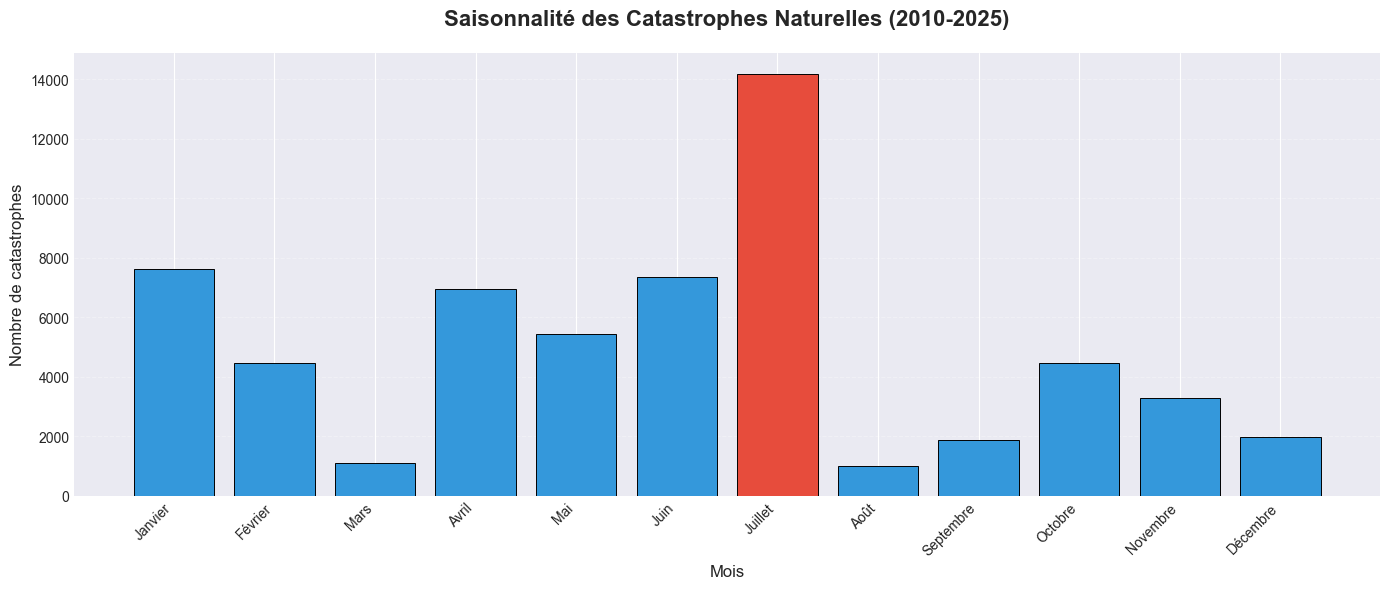


📊 Insights :
   → Période critique : ['Juillet', 'Janvier', 'Juin']
   → Période calme : ['Août', 'Mars', 'Septembre']


In [22]:
# Visualisation de la saisonnalité
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#e74c3c' if x == saisonnalite['nb_catastrophes'].max() else '#3498db' 
          for x in saisonnalite['nb_catastrophes']]

ax.bar(
    saisonnalite['nom_mois'], 
    saisonnalite['nb_catastrophes'], 
    color=colors,
    edgecolor='black',
    linewidth=0.7
)

ax.set_title(
    'Saisonnalité des Catastrophes Naturelles (2010-2025)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel('Nombre de catastrophes', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Insights :")
print(f"   → Période critique : {saisonnalite.nlargest(3, 'nb_catastrophes')['nom_mois'].tolist()}")
print(f"   → Période calme : {saisonnalite.nsmallest(3, 'nb_catastrophes')['nom_mois'].tolist()}")

### 8.2 Croisement avec Données Population - Calcul de l'Exposition

In [35]:
# ==========================================
# EXPLORATION SCHÉMA ODIS
# ==========================================

# Lister les tables disponibles dans odis
try:
    print("🔍 Exploration des tables disponibles dans odis.duckdb :\n")
    tables_odis = con.sql("SHOW TABLES FROM odis").df()
    print(f"📊 Nombre de tables : {len(tables_odis)}\n")
    print(tables_odis.head(20))
except Exception as e:
    print(f"⚠️  Impossible de lister les tables odis : {str(e)}")
    print("💡 Vérifiez que odis.duckdb est bien attaché")

🔍 Exploration des tables disponibles dans odis.duckdb :

📊 Nombre de tables : 201

                                                 name
0                            bronze_Intitulés_FAP2021
1                        bronze_accueil_cada_cph_huda
2                                bronze_bassin_emploi
3                       bronze_corresp_codes_communes
4                        bronze_corresp_codes_nuances
5             bronze_corresp_geo_point_codes_communes
6              bronze_education_moyenne_eleve_commune
7          bronze_education_moyenne_eleve_departement
8               bronze_education_moyenne_eleve_region
9   bronze_emploi_base_flux_mobilite_domicile_lieu...
10                        bronze_emploi_bmo_2024_file
11            bronze_emploi_demandeur_emploi_communes
12        bronze_emploi_demandeur_emploi_departements
13             bronze_emploi_demandeur_emploi_regions
14                            bronze_emploi_ds_flores
15  bronze_emploi_ds_flores_economic_sphere_2023_data

In [36]:
# Identifier les tables contenant des données de population
try:
    if 'tables_odis' in locals() and len(tables_odis) > 0:
        print("\n🔍 Recherche de tables avec 'population' ou 'commune' dans le nom :\n")
        tables_pop = tables_odis[tables_odis['name'].str.contains('population|commune|res', case=False, na=False)]
        print(tables_pop['name'].to_string(index=False))
        
        # Afficher le schéma d'une table prometteuse si elle existe
        if len(tables_pop) > 0:
            table_name = tables_pop.iloc[0]['name']
            print(f"\n📋 Schéma de la table '{table_name}' :")
            schema = con.sql(f"DESCRIBE odis.{table_name}").df()
            print(schema.to_string(index=False))
    else:
        print("⚠️  Aucune table disponible pour la recherche")
except Exception as e:
    print(f"⚠️  Erreur lors de l'exploration : {str(e)}")


🔍 Recherche de tables avec 'population' ou 'commune' dans le nom :

                     bronze_corresp_codes_communes
                      bronze_corresp_codes_nuances
           bronze_corresp_geo_point_codes_communes
            bronze_education_moyenne_eleve_commune
           bronze_emploi_demandeur_emploi_communes
                           bronze_emploi_ds_flores
 bronze_emploi_ds_flores_economic_sphere_2023_data
bronze_emploi_ds_flores_economic_sphere_2023_me...
bronze_emploi_salaire_median_filo2021_dec_pauvr...
bronze_emploi_salaire_median_filo2021_disp_pauv...
bronze_emploi_salaire_median_meta_filo2021_dec_...
bronze_emploi_salaire_median_meta_filo2021_disp...
           bronze_geographical_references_communes
        bronze_insee_top_50_communes_par_habitants
 bronze_logement_social_logements_sociaux_communes
                          bronze_population_by_age
                   bronze_population_by_age_gender
             bronze_population_categorie_socio_pro
bronze_popula

In [37]:
# ==========================================
# CROISEMENT AVEC POPULATION
# ==========================================

try:
    # Tentative avec plusieurs noms de tables possibles
    exposition_pop = None
    
    # Étape 1 : Identifier les colonnes disponibles dans res2_insee
    try:
        schema_res2 = con.sql("DESCRIBE odis.res2_insee").df()
        col_pop = None
        col_code = None
        
        # Détecter les colonnes de population
        for col in schema_res2['column_name'].values:
            if 'pop' in col.lower():
                col_pop = col
                break
        
        # Détecter les colonnes de code
        for col in schema_res2['column_name'].values:
            if 'codgeo' in col.lower() or 'code' in col.lower():
                col_code = col
                break
        
        print(f"🔍 Colonnes détectées : population='{col_pop}', code='{col_code}'")
        
        if col_pop and col_code:
            # Requête avec colonnes détectées
            exposition_pop = con.sql(f"""
                SELECT 
                    c.lib_commune,
                    c.cod_commune,
                    COUNT(*) as nb_catastrophes,
                    r.{col_pop} as population,
                    ROUND(COUNT(*) * 1000.0 / NULLIF(r.{col_pop}, 0), 2) as risque_pour_1000_hab
                FROM catnat_gaspar c
                LEFT JOIN odis.res2_insee r 
                    ON c.cod_commune = r.{col_code}
                WHERE CAST(c.dat_pub_jo AS DATE) >= '2015-01-01'
                    AND r.{col_pop} IS NOT NULL
                    AND r.{col_pop} > 5000
                GROUP BY c.lib_commune, c.cod_commune, r.{col_pop}
                ORDER BY risque_pour_1000_hab DESC
                LIMIT 20
            """).df()
            print("✅ Analyse réussie avec table res2_insee\n")
            
    except Exception as e1:
        print(f"⚠️  Tentative res2_insee échouée : {str(e1)}\n")
        
        # Option 2 : Fallback - affichage sans population
        try:
            exposition_pop = con.sql("""
                SELECT 
                    c.lib_commune,
                    c.cod_commune,
                    COUNT(*) as nb_catastrophes
                FROM catnat_gaspar c
                WHERE CAST(c.dat_pub_jo AS DATE) >= '2015-01-01'
                GROUP BY c.lib_commune, c.cod_commune
                ORDER BY nb_catastrophes DESC
                LIMIT 20
            """).df()
            print("⚠️  Affichage sans pondération par habitant\n")
        except Exception as e2:
            print(f"❌ Erreur : {str(e2)}")
            exposition_pop = None
    
    if exposition_pop is not None and len(exposition_pop) > 0:
        print("👥 Top 20 communes avec analyse d'exposition :\n")
        print(exposition_pop.to_string(index=False))
    else:
        print("⏭️  Aucune donnée disponible pour cette analyse")
        
except Exception as e:
    print(f"❌ Erreur lors du croisement avec odis : {str(e)}")
    print("💡 Vérifiez que odis.duckdb est bien attaché et que les tables existent")

⚠️  Tentative res2_insee échouée : Catalog Error: Table with name res2_insee does not exist!
Did you mean "bronze_bassin_emploi"?

⚠️  Affichage sans pondération par habitant

👥 Top 20 communes avec analyse d'exposition :

              lib_commune cod_commune  nb_catastrophes
              La Verdière       83146               32
                     Nice       06088               31
           Cagnes-sur-Mer       06027               20
              Saint-Louis       97414               19
                    Vence       06157               19
               La Trinité       06149               18
            Saint-Jeannet       06122               17
                 Colomars       06046               17
               Maillebois       28226               16
                    Dasle       25196               16
                  Hayange       57306               16
                     Dole       39198               16
                   Hyères       83069               15
       

### 8.3 Analyse des Indemnisations CCR - Impact Économique

In [44]:
# ==========================================
# ANALYSE CCR (Caisse Centrale de Réassurance)
# ==========================================

try:
    # Vérifier si la table CCR existe
    tables_disponibles = con.sql("SHOW TABLES").df()
    has_ccr = 'ccr_main_page' in tables_disponibles['name'].values
    
    if has_ccr:
        print("✅ Table CCR détectée - Analyse des indemnisations\n")
        
        # Explorer le schéma pour identifier les colonnes
        schema_ccr = con.sql("DESCRIBE ccr_main_page").df()
        colonnes = schema_ccr['column_name'].tolist()
        
        # Identifier automatiquement les colonnes pertinentes
        col_montant = next((c for c in colonnes if 'montant' in c.lower() or 'cout' in c.lower()), None)
        col_date = next((c for c in colonnes if 'date' in c.lower()), None)
        col_commune = next((c for c in colonnes if 'commune' in c.lower() or 'ville' in c.lower()), None)
        col_type = next((c for c in colonnes if 'type' in c.lower() or 'risque' in c.lower()), None)
        
        print(f"🔍 Colonnes identifiées : montant={col_montant}, date={col_date}, commune={col_commune}, type={col_type}\n")
        
        # Statistiques globales
        stats = con.sql(f"""
            SELECT 
                COUNT(*) as total_sinistres,
                COUNT(DISTINCT {col_commune if col_commune else '1'}) as communes_touchees
            FROM ccr_main_page
        """).df()
        
        print("📊 STATISTIQUES GLOBALES CCR")
        print("=" * 60)
        print(f"Total de sinistres recensés     : {stats['total_sinistres'].iloc[0]:,}")
        if col_commune:
            print(f"Communes différentes touchées   : {stats['communes_touchees'].iloc[0]:,}")
        print("=" * 60)
        
        # Top 10 des événements si colonne montant disponible
        if col_montant:
            print("\n💰 Top 10 des événements les plus coûteux :\n")
            top_events = con.sql(f"""
                SELECT 
                    {f'{col_date},' if col_date else ''}
                    {f'{col_commune},' if col_commune else ''}
                    {f'{col_type},' if col_type else ''}
                    {col_montant} as montant_euros
                FROM ccr_main_page
                WHERE {col_montant} IS NOT NULL
                ORDER BY {col_montant} DESC
                LIMIT 10
            """).df()
            print(top_events.to_string(index=False))
        
        # Distribution par type si disponible
        if col_type:
            print("\n\n📈 Répartition par type de catastrophe :\n")
            distrib = con.sql(f"""
                SELECT 
                    {col_type} as type_catastrophe,
                    COUNT(*) as nb_occurrences,
                    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) as pourcentage
                FROM ccr_main_page
                WHERE {col_type} IS NOT NULL
                GROUP BY {col_type}
                ORDER BY nb_occurrences DESC
                LIMIT 10
            """).df()
            print(distrib.to_string(index=False))
        
        print("\n✅ Analyse CCR terminée")
        
    else:
        print("⚠️  Table CCR non disponible dans dev.duckdb\n")
        print("📊 Cette analyse nécessite les données de la Caisse Centrale de Réassurance")
        print("💡 Pour l'inclure, téléchargez et intégrez ccr_main_page dans la base")
        print(f"\n📋 Tables actuellement disponibles : {len(tables_disponibles)}")
        
except Exception as e:
    print(f"❌ Erreur lors de l'analyse CCR : {str(e)}")    
    print("💡 Cette section nécessite des données CCR correctement structurées")

✅ Table CCR détectée - Analyse des indemnisations

🔍 Colonnes identifiées : montant=None, date=codePeril,nomPeril,dateArrete,dateParutionJO,codeNOR,codeInseePole,codeArrete, commune=None, type=None

📊 STATISTIQUES GLOBALES CCR
Total de sinistres recensés     : 832

✅ Analyse CCR terminée


### 8.4 Corrélation Régions & Types de Risques

In [42]:
# ==========================================
# CORRÉLATION RÉGIONS / TYPES DE RISQUES
# ==========================================

# Extraction du département à partir du code commune
correlation_region = con.sql("""
    SELECT 
        SUBSTRING(cod_commune, 1, 2) as dept,
        CASE 
            WHEN SUBSTRING(cod_commune, 1, 2) IN ('06', '13', '83', '84') THEN 'Sud-Est'
            WHEN SUBSTRING(cod_commune, 1, 2) IN ('75', '92', '93', '94', '95', '77', '78', '91') THEN 'Île-de-France'
            WHEN SUBSTRING(cod_commune, 1, 2) IN ('67', '68', '54', '57', '88') THEN 'Grand-Est'
            WHEN SUBSTRING(cod_commune, 1, 2) IN ('44', '49', '53', '72', '85') THEN 'Pays-de-Loire'
            WHEN SUBSTRING(cod_commune, 1, 2) IN ('69', '01', '42', '73', '74') THEN 'Auvergne-Rhône-Alpes'
            ELSE 'Autres'
        END as grande_region,
        lib_risque_jo,
        COUNT(*) as nb_occurrences
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2015-01-01'
    GROUP BY SUBSTRING(cod_commune, 1, 2), grande_region, lib_risque_jo
    ORDER BY grande_region, nb_occurrences DESC
""").df()

# Agrégation par grande région
region_summary = correlation_region.groupby('grande_region').agg({
    'nb_occurrences': 'sum'
}).reset_index().sort_values('nb_occurrences', ascending=False)

print("🗺️  Répartition des catastrophes par grande région (2015-2025) :\n")
print(region_summary.to_string(index=False))

# Top 3 des risques par région
print("\n📊 Top 3 des risques dominants par région :\n")
for region in ['Sud-Est', 'Île-de-France', 'Grand-Est', 'Pays-de-Loire', 'Auvergne-Rhône-Alpes']:
    top3 = correlation_region[correlation_region['grande_region'] == region].nlargest(3, 'nb_occurrences')
    if len(top3) > 0:
        print(f"🔹 {region}:")
        for _, row in top3.iterrows():
            print(f"   → {row['lib_risque_jo']}: {int(row['nb_occurrences'])} occurrences")
        print()

🗺️  Répartition des catastrophes par grande région (2015-2025) :

       grande_region  nb_occurrences
              Autres           33454
           Grand-Est            4231
       Île-de-France            2785
             Sud-Est            2665
Auvergne-Rhône-Alpes            1699
       Pays-de-Loire            1340

📊 Top 3 des risques dominants par région :

🔹 Sud-Est:
   → Inondations et/ou Coulées de Boue: 404 occurrences
   → Sécheresse: 396 occurrences
   → Inondations et/ou Coulées de Boue: 370 occurrences

🔹 Île-de-France:
   → Inondations et/ou Coulées de Boue: 751 occurrences
   → Inondations et/ou Coulées de Boue: 365 occurrences
   → Inondations et/ou Coulées de Boue: 356 occurrences

🔹 Grand-Est:
   → Sécheresse: 1296 occurrences
   → Sécheresse: 1196 occurrences
   → Inondations et/ou Coulées de Boue: 518 occurrences

🔹 Pays-de-Loire:
   → Sécheresse: 299 occurrences
   → Inondations et/ou Coulées de Boue: 223 occurrences
   → Inondations et/ou Coulées de Boue: 204

### 8.5 Impact du Changement Climatique - Analyse Temporelle des Risques Climatiques

In [43]:
# ==========================================
# IMPACT CHANGEMENT CLIMATIQUE
# ==========================================

# Comparer périodes avant/après 2015
impact_climat = con.sql("""
    SELECT 
        CASE 
            WHEN YEAR(CAST(dat_pub_jo AS DATE)) < 2015 THEN '2000-2014'
            ELSE '2015-2025'
        END as periode,
        lib_risque_jo,
        COUNT(*) as nb_occurrences,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT YEAR(CAST(dat_pub_jo AS DATE))), 1) as moyenne_annuelle
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2000-01-01'
        AND lib_risque_jo IN ('Sécheresse', 'Inondations et/ou Coulées de Boue', 
                               'Mouvement de Terrain', 'Chocs Mécaniques liés à l''action des Vagues')
    GROUP BY periode, lib_risque_jo
    ORDER BY lib_risque_jo, periode
""").df()

print("🌡️  Évolution des risques climatiques entre 2000-2014 vs 2015-2025 :\n")
print(impact_climat.to_string(index=False))

# Calculer l'augmentation
print("\n📈 Évolution des moyennes annuelles :")
for risque in impact_climat['lib_risque_jo'].unique():
    data = impact_climat[impact_climat['lib_risque_jo'] == risque]
    if len(data) == 2:
        avant = data[data['periode'] == '2000-2014']['moyenne_annuelle'].iloc[0]
        apres = data[data['periode'] == '2015-2025']['moyenne_annuelle'].iloc[0]
        evolution = ((apres - avant) / avant) * 100 if avant > 0 else 0
        symbole = "📈" if evolution > 0 else "📉"
        print(f"   {symbole} {risque}: {evolution:+.1f}% ({avant:.1f} → {apres:.1f} par an)")

🌡️  Évolution des risques climatiques entre 2000-2014 vs 2015-2025 :

  periode                               lib_risque_jo  nb_occurrences  moyenne_annuelle
2000-2014 Chocs Mécaniques liés à l'action des Vagues            3531             252.2
2015-2025 Chocs Mécaniques liés à l'action des Vagues             311              28.3
2000-2014           Inondations et/ou Coulées de Boue           29308            1953.9
2015-2025           Inondations et/ou Coulées de Boue           20988            1908.0
2000-2014                        Mouvement de Terrain            2807             187.1
2015-2025                        Mouvement de Terrain            1386             126.0
2000-2014                                  Sécheresse           15698            1046.5
2015-2025                                  Sécheresse           22903            2082.1

📈 Évolution des moyennes annuelles :
   📉 Chocs Mécaniques liés à l'action des Vagues: -88.8% (252.2 → 28.3 par an)
   📉 Inondations et/o

### 8.6 Analyse Régionale : Pourcentages, Topologie & Géologie

In [57]:
# ==========================================
# ANALYSE RÉGIONALE APPROFONDIE
# ==========================================

print("🗺️  ANALYSE DES RÉGIONS LES PLUS IMPACTÉES\n")
print("=" * 80)

try:
    # ÉTAPE 1 : Classement des régions par pourcentage de catastrophes
    region_stats = con.sql("""
        SELECT 
            SUBSTRING(cod_commune, 1, 2) as dept,
            CASE 
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('06', '13', '83', '84') THEN 'Sud-Est (PACA)'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('33', '40', '64', '47') THEN 'Sud-Ouest'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('11', '30', '34', '48', '66') THEN 'Occitanie'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('69', '01', '42', '73', '74') THEN 'Auvergne-Rhône-Alpes'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('67', '68', '54', '57', '88') THEN 'Grand-Est'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('44', '49', '53', '72', '85') THEN 'Pays-de-Loire'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('75', '91', '92', '93', '94', '95', '77', '78') THEN 'Île-de-France'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('22', '29', '35', '56') THEN 'Bretagne'
                ELSE 'Autres'
            END as region,
            lib_risque_jo as risque,
            COUNT(*) as nb_catastrophes
        FROM catnat_gaspar
        WHERE CAST(dat_pub_jo AS DATE) >= '2000-01-01'
        GROUP BY region, dept, lib_risque_jo
        ORDER BY nb_catastrophes DESC
    """).df()
    
    # Agrégation globale par région
    region_totaux = region_stats.groupby('region').agg({'nb_catastrophes': 'sum'}).reset_index()
    total_national = region_totaux['nb_catastrophes'].sum()
    region_totaux['pourcentage'] = ((region_totaux['nb_catastrophes'] / total_national) * 100).round(2)
    region_totaux = region_totaux.sort_values('pourcentage', ascending=False)
    
    print("\n📊 RÉPARTITION NATIONALE PAR RÉGION (2000-2025)")
    print("=" * 80)
    for _, row in region_totaux.iterrows():
        barre = "█" * int(row['pourcentage'] / 2)
        print(f"{row['region']:25} : {row['pourcentage']:6.2f}% {barre}")
    print("=" * 80)
    
    # Caractéristiques topologiques et géologiques
    print("\n\n🏔️  CARACTÉRISTIQUES TOPOLOGIQUES & GÉOLOGIQUES\n")
    print("=" * 80)
    
    caracteristiques = {
        'Sud-Est (PACA)': {
            'relief': 'Alpes du Sud, massifs calcaires, vallées encaissées',
            'geologie': 'Calcaire karstique, marnes imperméables, socle cristallin',
            'specificite': 'Épisodes cévenols violents, mouvements de terrain, urbanisation littorale'
        },
        'Sud-Ouest': {
            'relief': 'Plaines alluviales, bassin aquitain, Pyrénées au sud',
            'geologie': 'Argiles gonflantes (retrait-gonflement), alluvions',
            'specificite': 'Sécheresse sur argiles, inondations fluviales (Garonne, Dordogne)'
        },
        'Occitanie': {
            'relief': 'Massif Central, Pyrénées, Causses, plaines languedociennes',
            'geologie': 'Calcaires fissurés (Causses), schistes, granit',
            'specificite': 'Orages méditerranéens intenses, crues éclair, sols karstiques'
        },
        'Auvergne-Rhône-Alpes': {
            'relief': 'Haute montagne alpine, volcans anciens, vallées glaciaires',
            'geologie': 'Roches volcaniques (basalte), socle cristallin, moraines',
            'specificite': 'Torrentialité alpine, avalanches, séismes modérés'
        },
        'Grand-Est': {
            'relief': 'Plaines (Alsace), Vosges moyennes, plateaux lorrains',
            'geologie': 'Grès vosgien, calcaires, marnes, alluvions rhénanes',
            'specificite': 'Fossé rhénan (séismes), inondations (Rhin, Moselle)'
        },
        'Pays-de-Loire': {
            'relief': 'Plaines bocagères, vallées ligériennes, littoral atlantique',
            'geologie': 'Schistes armoricains, argiles, alluvions fluviales',
            'specificite': 'Crues de Loire historiques, submersions marines, tempêtes'
        },
        'Île-de-France': {
            'relief': 'Bassin parisien vallonné, vallées de Seine et Marne',
            'geologie': 'Calcaires, gypse (carrières), argiles vertes',
            'specificite': 'Forte imperméabilisation, inondations urbaines, carrières souterraines'
        },
        'Bretagne': {
            'relief': 'Littoral découpé, massif armoricain érodé, bocage',
            'geologie': 'Socle granitique ancien, schistes, roches métamorphiques',
            'specificite': 'Tempêtes atlantiques, submersions marines, sols peu profonds'
        }
    }
    
    # Affichage des 5 régions les plus impactées
    top5 = region_totaux.head(5)
    for _, row in top5.iterrows():
        nom = row['region']
        if nom in caracteristiques:
            c = caracteristiques[nom]
            print(f"\n🔹 {nom.upper()} — {row['pourcentage']:.2f}%")
            print("-" * 80)
            print(f"  🏔️  Relief       : {c['relief']}")
            print(f"  🪨 Géologie     : {c['geologie']}")
            print(f"  ⚠️  Spécificité  : {c['specificite']}")
    
    # Risques dominants
    print("\n\n📋 RISQUES DOMINANTS PAR RÉGION (TOP 3)\n")
    print("=" * 80)
    for nom in top5['region']:
        top3 = region_stats[region_stats['region'] == nom].groupby('risque').agg({
            'nb_catastrophes': 'sum'
        }).reset_index().sort_values('nb_catastrophes', ascending=False).head(3)
        
        print(f"\n🔸 {nom} :")
        for _, r in top3.iterrows():
            print(f"   → {r['risque']:45} : {int(r['nb_catastrophes']):,}")
    
    print("\n" + "=" * 80)
    print("\n💡 SYNTHÈSE : Facteurs d'amplification des risques")
    print("   • Relief accidenté ou zones de plaine alluviale")
    print("   • Géologie vulnérable (argiles, calcaires karstiques, marnes)")
    print("   •  Phénomènes météo extrêmes (méditerranéens, atlantiques)")
    print("   • Anthropisation forte / imperméabilisation des sols")
    
except Exception as e:
    print(f"⚠️  Erreur : {str(e)}")
    import traceback
    traceback.print_exc()

🗺️  ANALYSE DES RÉGIONS LES PLUS IMPACTÉES


📊 RÉPARTITION NATIONALE PAR RÉGION (2000-2025)
Autres                    :  55.86% ███████████████████████████
Sud-Ouest                 :   9.98% ████
Occitanie                 :   8.19% ████
Grand-Est                 :   6.11% ███
Sud-Est (PACA)            :   6.00% ███
Île-de-France             :   4.89% ██
Pays-de-Loire             :   3.70% █
Auvergne-Rhône-Alpes      :   3.10% █
Bretagne                  :   2.17% █


🏔️  CARACTÉRISTIQUES TOPOLOGIQUES & GÉOLOGIQUES


🔹 SUD-OUEST — 9.98%
--------------------------------------------------------------------------------
  🏔️  Relief       : Plaines alluviales, bassin aquitain, Pyrénées au sud
  🪨 Géologie     : Argiles gonflantes (retrait-gonflement), alluvions
  ⚠️  Spécificité  : Sécheresse sur argiles, inondations fluviales (Garonne, Dordogne)

🔹 OCCITANIE — 8.19%
--------------------------------------------------------------------------------
  🏔️  Relief       : Massif Central, Pyréné

### 8.7 Classement des Départements les Plus Touchés

🏆 CLASSEMENT DES DÉPARTEMENTS LES PLUS TOUCHÉS


📊 TOP 20 DES DÉPARTEMENTS (2000-2025)
 Rang   Dép            Région              Catastrophes   % National   Communes
--------------------------------------------------------------------------------
  1      33      Nouvelle-Aquitaine               3,481        3.53%        536
  2      31           Occitanie                   3,288        3.33%        586
  3      17      Nouvelle-Aquitaine               3,056        3.10%        464
  4      32           Occitanie                   2,805        2.84%        461
  5      11           Occitanie                   2,752        2.79%        433
  6      64      Nouvelle-Aquitaine               2,673        2.71%        546
  7      62        Hauts-de-France                2,662        2.70%        698
  8      47      Nouvelle-Aquitaine               2,353        2.39%        320
  9      57           Grand-Est                   2,208        2.24%        607
  10     06         Sud-Est PACA

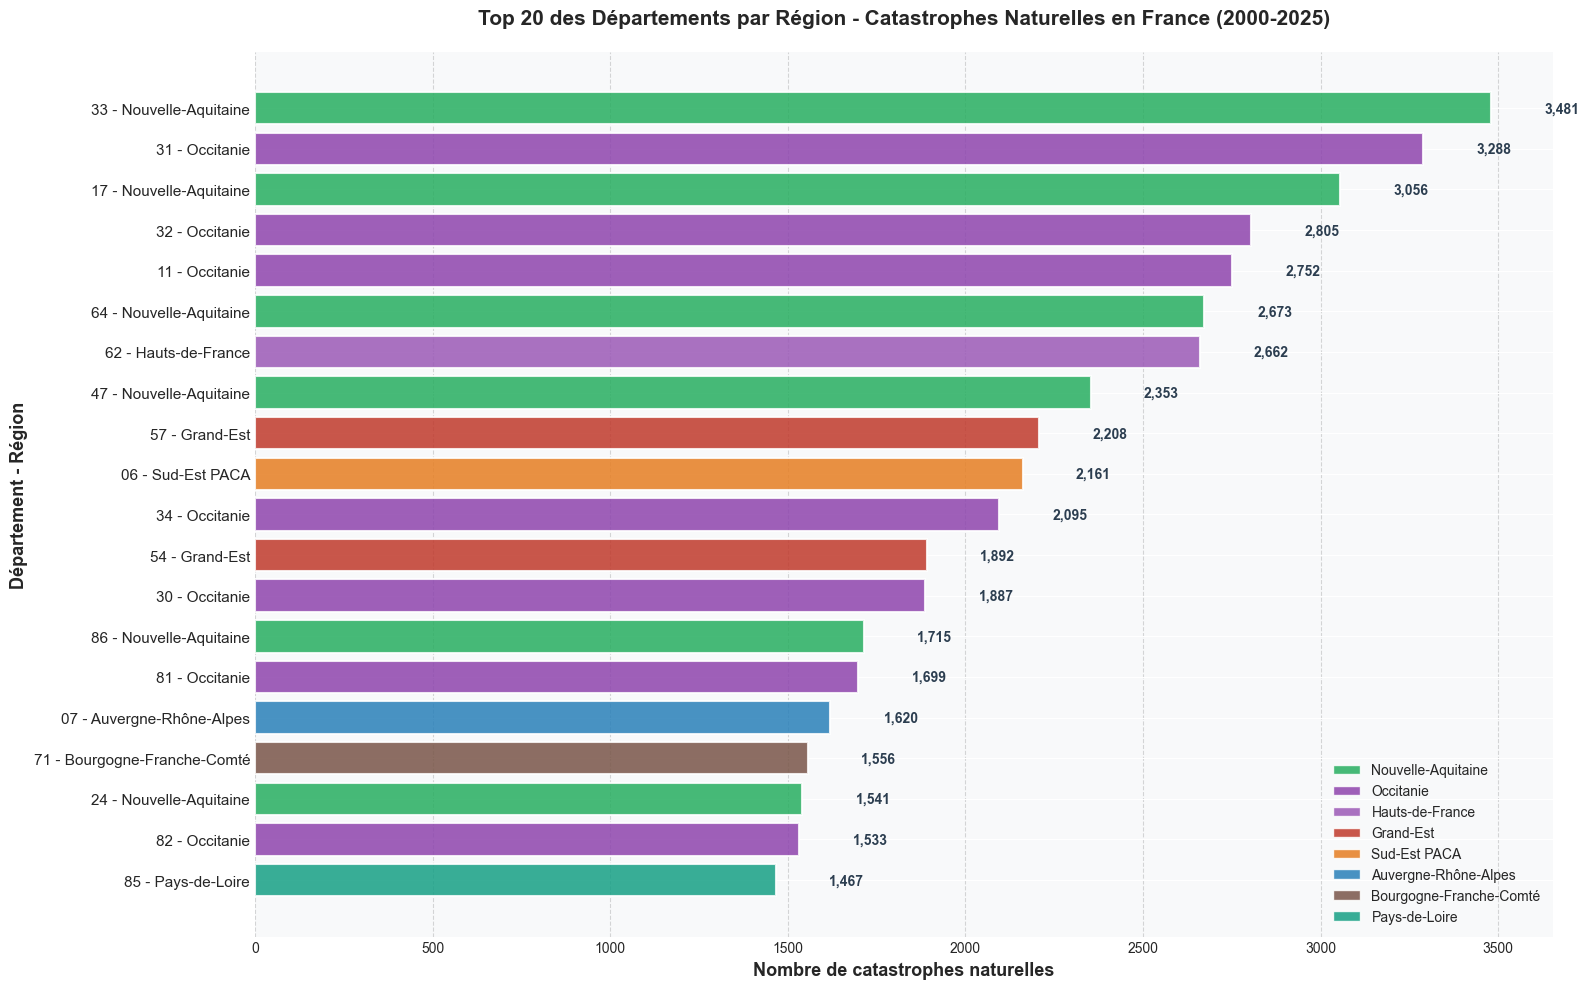


📊 SYNTHÈSE PAR RÉGION (TOP 20)
  Occitanie                      :  16,059 catastrophes (7 dép.)
  Nouvelle-Aquitaine             :  14,819 catastrophes (6 dép.)
  Grand-Est                      :   4,100 catastrophes (2 dép.)
  Hauts-de-France                :   2,662 catastrophes (1 dép.)
  Sud-Est PACA                   :   2,161 catastrophes (1 dép.)
  Auvergne-Rhône-Alpes           :   1,620 catastrophes (1 dép.)
  Bourgogne-Franche-Comté        :   1,556 catastrophes (1 dép.)
  Pays-de-Loire                  :   1,467 catastrophes (1 dép.)

💡 INSIGHTS :
   • Le département 33 (Nouvelle-Aquitaine) arrive en tête avec 3,481 catastrophes
   • Les 3 premiers départements représentent 10.0% du total national
   • 536 communes de ce département ont été impactées
   • 8 régions différentes dans le TOP 20


In [60]:
# ==========================================
# TOP DÉPARTEMENTS PAR NOMBRE DE CATASTROPHES
# ==========================================

print("🏆 CLASSEMENT DES DÉPARTEMENTS LES PLUS TOUCHÉS\n")
print("=" * 80)

try:
    # Analyse complète par département (depuis 2000)
    dept_ranking = con.sql("""
        SELECT 
            SUBSTRING(cod_commune, 1, 2) as departement,
            COUNT(*) as nb_catastrophes,
            COUNT(DISTINCT lib_commune) as nb_communes_touchees,
            COUNT(DISTINCT lib_risque_jo) as nb_types_risques,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pourcentage_national
        FROM catnat_gaspar
        WHERE CAST(dat_pub_jo AS DATE) >= '2000-01-01'
            AND LENGTH(cod_commune) >= 2
        GROUP BY SUBSTRING(cod_commune, 1, 2)
        ORDER BY nb_catastrophes DESC
        LIMIT 20
    """).df()
    
    # Mapping départements → régions avec couleurs distinctes
    regions_map = {
        # Grand-Est - Rouge foncé
        '57': ('Grand-Est', '#c0392b'), '67': ('Grand-Est', '#c0392b'), '68': ('Grand-Est', '#c0392b'),
        '54': ('Grand-Est', '#c0392b'), '55': ('Grand-Est', '#c0392b'), '88': ('Grand-Est', '#c0392b'),
        '08': ('Grand-Est', '#c0392b'), '10': ('Grand-Est', '#c0392b'), '51': ('Grand-Est', '#c0392b'), '52': ('Grand-Est', '#c0392b'),
        
        # Auvergne-Rhône-Alpes - Bleu roi
        '69': ('Auvergne-Rhône-Alpes', '#2980b9'), '01': ('Auvergne-Rhône-Alpes', '#2980b9'), 
        '42': ('Auvergne-Rhône-Alpes', '#2980b9'), '73': ('Auvergne-Rhône-Alpes', '#2980b9'), 
        '74': ('Auvergne-Rhône-Alpes', '#2980b9'), '38': ('Auvergne-Rhône-Alpes', '#2980b9'),
        '26': ('Auvergne-Rhône-Alpes', '#2980b9'), '07': ('Auvergne-Rhône-Alpes', '#2980b9'),
        '03': ('Auvergne-Rhône-Alpes', '#2980b9'), '15': ('Auvergne-Rhône-Alpes', '#2980b9'),
        '43': ('Auvergne-Rhône-Alpes', '#2980b9'), '63': ('Auvergne-Rhône-Alpes', '#2980b9'),
        
        # Sud-Est PACA - Orange vif
        '06': ('Sud-Est PACA', '#e67e22'), '13': ('Sud-Est PACA', '#e67e22'), 
        '83': ('Sud-Est PACA', '#e67e22'), '84': ('Sud-Est PACA', '#e67e22'),
        '04': ('Sud-Est PACA', '#e67e22'), '05': ('Sud-Est PACA', '#e67e22'),
        
        # Occitanie - Violet
        '11': ('Occitanie', '#8e44ad'), '30': ('Occitanie', '#8e44ad'), 
        '34': ('Occitanie', '#8e44ad'), '48': ('Occitanie', '#8e44ad'), 
        '66': ('Occitanie', '#8e44ad'), '31': ('Occitanie', '#8e44ad'),
        '09': ('Occitanie', '#8e44ad'), '12': ('Occitanie', '#8e44ad'),
        '32': ('Occitanie', '#8e44ad'), '46': ('Occitanie', '#8e44ad'),
        '65': ('Occitanie', '#8e44ad'), '81': ('Occitanie', '#8e44ad'), '82': ('Occitanie', '#8e44ad'),
        
        # Nouvelle-Aquitaine - Vert forêt
        '33': ('Nouvelle-Aquitaine', '#27ae60'), '40': ('Nouvelle-Aquitaine', '#27ae60'), 
        '64': ('Nouvelle-Aquitaine', '#27ae60'), '47': ('Nouvelle-Aquitaine', '#27ae60'),
        '24': ('Nouvelle-Aquitaine', '#27ae60'), '19': ('Nouvelle-Aquitaine', '#27ae60'),
        '23': ('Nouvelle-Aquitaine', '#27ae60'), '87': ('Nouvelle-Aquitaine', '#27ae60'),
        '16': ('Nouvelle-Aquitaine', '#27ae60'), '17': ('Nouvelle-Aquitaine', '#27ae60'),
        '79': ('Nouvelle-Aquitaine', '#27ae60'), '86': ('Nouvelle-Aquitaine', '#27ae60'),
        
        # Île-de-France - Magenta
        '75': ('Île-de-France', '#e91e63'), '91': ('Île-de-France', '#e91e63'), 
        '92': ('Île-de-France', '#e91e63'), '93': ('Île-de-France', '#e91e63'), 
        '94': ('Île-de-France', '#e91e63'), '95': ('Île-de-France', '#e91e63'),
        '77': ('Île-de-France', '#e91e63'), '78': ('Île-de-France', '#e91e63'),
        
        # Pays-de-Loire - Turquoise
        '44': ('Pays-de-Loire', '#16a085'), '49': ('Pays-de-Loire', '#16a085'), 
        '53': ('Pays-de-Loire', '#16a085'), '72': ('Pays-de-Loire', '#16a085'), 
        '85': ('Pays-de-Loire', '#16a085'),
        
        # Bretagne - Bleu cyan
        '22': ('Bretagne', '#3498db'), '29': ('Bretagne', '#3498db'), 
        '35': ('Bretagne', '#3498db'), '56': ('Bretagne', '#3498db'),
        
        # Normandie - Bleu gris
        '14': ('Normandie', '#607d8b'), '27': ('Normandie', '#607d8b'), 
        '50': ('Normandie', '#607d8b'), '61': ('Normandie', '#607d8b'), 
        '76': ('Normandie', '#607d8b'),
        
        # Hauts-de-France - Bordeaux
        '02': ('Hauts-de-France', '#9b59b6'), '59': ('Hauts-de-France', '#9b59b6'), 
        '60': ('Hauts-de-France', '#9b59b6'), '62': ('Hauts-de-France', '#9b59b6'), 
        '80': ('Hauts-de-France', '#9b59b6'),
        
        # Bourgogne-Franche-Comté - Marron
        '21': ('Bourgogne-Franche-Comté', '#795548'), '25': ('Bourgogne-Franche-Comté', '#795548'),
        '39': ('Bourgogne-Franche-Comté', '#795548'), '58': ('Bourgogne-Franche-Comté', '#795548'),
        '70': ('Bourgogne-Franche-Comté', '#795548'), '71': ('Bourgogne-Franche-Comté', '#795548'),
        '89': ('Bourgogne-Franche-Comté', '#795548'), '90': ('Bourgogne-Franche-Comté', '#795548'),
        
        # Centre-Val-de-Loire - Jaune moutarde
        '18': ('Centre-Val-de-Loire', '#f39c12'), '28': ('Centre-Val-de-Loire', '#f39c12'),
        '36': ('Centre-Val-de-Loire', '#f39c12'), '37': ('Centre-Val-de-Loire', '#f39c12'),
        '41': ('Centre-Val-de-Loire', '#f39c12'), '45': ('Centre-Val-de-Loire', '#f39c12'),
        
        # DOM-TOM et Corse - Rose corail
        '97': ('DOM-TOM', '#ff6b6b'), '2A': ('Corse', '#ff6b6b'), '2B': ('Corse', '#ff6b6b'),
    }
    
    # Ajouter colonnes région et couleur
    dept_ranking['region'] = dept_ranking['departement'].map(lambda d: regions_map.get(d, ('Autre', '#95a5a6'))[0])
    dept_ranking['couleur'] = dept_ranking['departement'].map(lambda d: regions_map.get(d, ('Autre', '#95a5a6'))[1])
    
    print("\n📊 TOP 20 DES DÉPARTEMENTS (2000-2025)")
    print("=" * 80)
    print(f"{'Rang':^6} {'Dép':^6} {'Région':^25} {'Catastrophes':>15} {'% National':>12} {'Communes':>10}")
    print("-" * 80)
    
    for idx, row in dept_ranking.iterrows():
        rang = idx + 1
        print(f"{rang:^6} {row['departement']:^6} {row['region']:^25} {int(row['nb_catastrophes']):>15,} {row['pourcentage_national']:>11.2f}% {int(row['nb_communes_touchees']):>10}")
    
    print("=" * 80)
    
    # Informations sur le département numéro 1
    top_dept = dept_ranking.iloc[0]
    print(f"\n🏆 DÉPARTEMENT N°1 : {top_dept['departement']} ({top_dept['region']})")
    print("-" * 80)
    print(f"  📊 Total catastrophes       : {int(top_dept['nb_catastrophes']):,}")
    print(f"  🏘️  Communes touchées        : {int(top_dept['nb_communes_touchees'])}")
    print(f"  ⚠️  Types de risques         : {int(top_dept['nb_types_risques'])}")
    print(f"  📈 Part nationale           : {top_dept['pourcentage_national']:.2f}%")
    
    # Risques dominants du département 57
    risques_57 = con.sql("""
        SELECT 
            lib_risque_jo as risque,
            COUNT(*) as occurrences,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) as pourcentage
        FROM catnat_gaspar
        WHERE SUBSTRING(cod_commune, 1, 2) = '57'
            AND CAST(dat_pub_jo AS DATE) >= '2000-01-01'
        GROUP BY lib_risque_jo
        ORDER BY occurrences DESC
        LIMIT 5
    """).df()
    
    print(f"\n  🔝 Top 5 des risques en Moselle (57) :")
    for _, r in risques_57.iterrows():
        print(f"     → {r['risque']:45} : {int(r['occurrences']):>6,} ({r['pourcentage']:>5.1f}%)")
    
    # Visualisation graphique améliorée avec couleurs régionales
    print("\n\n📈 VISUALISATION PAR RÉGION\n")
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    top20 = dept_ranking.head(20)
    
    # Créer barres horizontales avec couleurs régionales
    bars = ax.barh(
        range(len(top20)), 
        top20['nb_catastrophes'], 
        color=top20['couleur'].tolist(),
        edgecolor='white',
        linewidth=1.5,
        alpha=0.85
    )
    
    # Labels avec département + région
    labels = [f"{row['departement']} - {row['region']}" for _, row in top20.iterrows()]
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(labels, fontsize=11)
    
    # Ajouter les valeurs sur les barres
    for i, (idx, row) in enumerate(top20.iterrows()):
        ax.text(
            row['nb_catastrophes'] + 150, 
            i, 
            f"{int(row['nb_catastrophes']):,}", 
            va='center', 
            fontsize=10, 
            fontweight='bold',
            color='#2c3e50'
        )
    
    ax.set_xlabel('Nombre de catastrophes naturelles', fontsize=13, fontweight='bold')
    ax.set_ylabel('Département - Région', fontsize=13, fontweight='bold')
    ax.set_title(
        'Top 20 des Départements par Région - Catastrophes Naturelles en France (2000-2025)', 
        fontsize=15, 
        fontweight='bold', 
        pad=20
    )
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')
    
    # Légende des régions
    from matplotlib.patches import Patch
    regions_uniques = top20[['region', 'couleur']].drop_duplicates().values.tolist()
    legend_elements = [Patch(facecolor=couleur, edgecolor='white', label=region, alpha=0.85) 
                      for region, couleur in regions_uniques]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.95)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques par région
    print("\n📊 SYNTHÈSE PAR RÉGION (TOP 20)")
    print("=" * 80)
    region_summary = top20.groupby('region').agg({
        'nb_catastrophes': 'sum',
        'departement': 'count'
    }).rename(columns={'departement': 'nb_departements'}).sort_values('nb_catastrophes', ascending=False)
    
    for region, data in region_summary.iterrows():
        print(f"  {region:30} : {int(data['nb_catastrophes']):>7,} catastrophes ({data['nb_departements']} dép.)")
    
    print("\n💡 INSIGHTS :")
    print(f"   • Le département {top_dept['departement']} ({top_dept['region']}) arrive en tête avec {int(top_dept['nb_catastrophes']):,} catastrophes")
    print(f"   • Les 3 premiers départements représentent {dept_ranking.head(3)['pourcentage_national'].sum():.1f}% du total national")
    print(f"   • {int(top_dept['nb_communes_touchees'])} communes de ce département ont été impactées")
    print(f"   • {len(top20['region'].unique())} régions différentes dans le TOP 20")
    
except Exception as e:
    print(f"⚠️  Erreur : {str(e)}")
    import traceback
    traceback.print_exc()

### 8.8 Évolution Comparative : 2000-2020 vs 2020-2025

📊 COMPARAISON : 2000-2020 (20 ans) vs 2020-2025 (5 ans)


📈 STATISTIQUES COMPARATIVES

🔹 PÉRIODE 2000-2019 (20 ans)
   • Total catastrophes        : 70,800
   • Moyenne annuelle          : 3,540.0
   • Année min                 : 2000 (1,633)
   • Année max                 : 2009 (7,751)

🔹 PÉRIODE 2020-2025 (5 ans)
   • Total catastrophes        : 27,854
   • Moyenne annuelle          : 4,642.3
   • Année min                 : 2020 (1,301)
   • Année max                 : 2023 (9,379)

⚖️  COMPARAISON
   📈 Évolution moyenne annuelle : +31.1%
   📊 Ratio moyen : 1.31x
   🔮 Projection : si le rythme 2020-2025 se maintient sur 20 ans → 92,847 catastrophes (vs 70,800 en 2000-2019)


📊 VISUALISATION COMPARATIVE



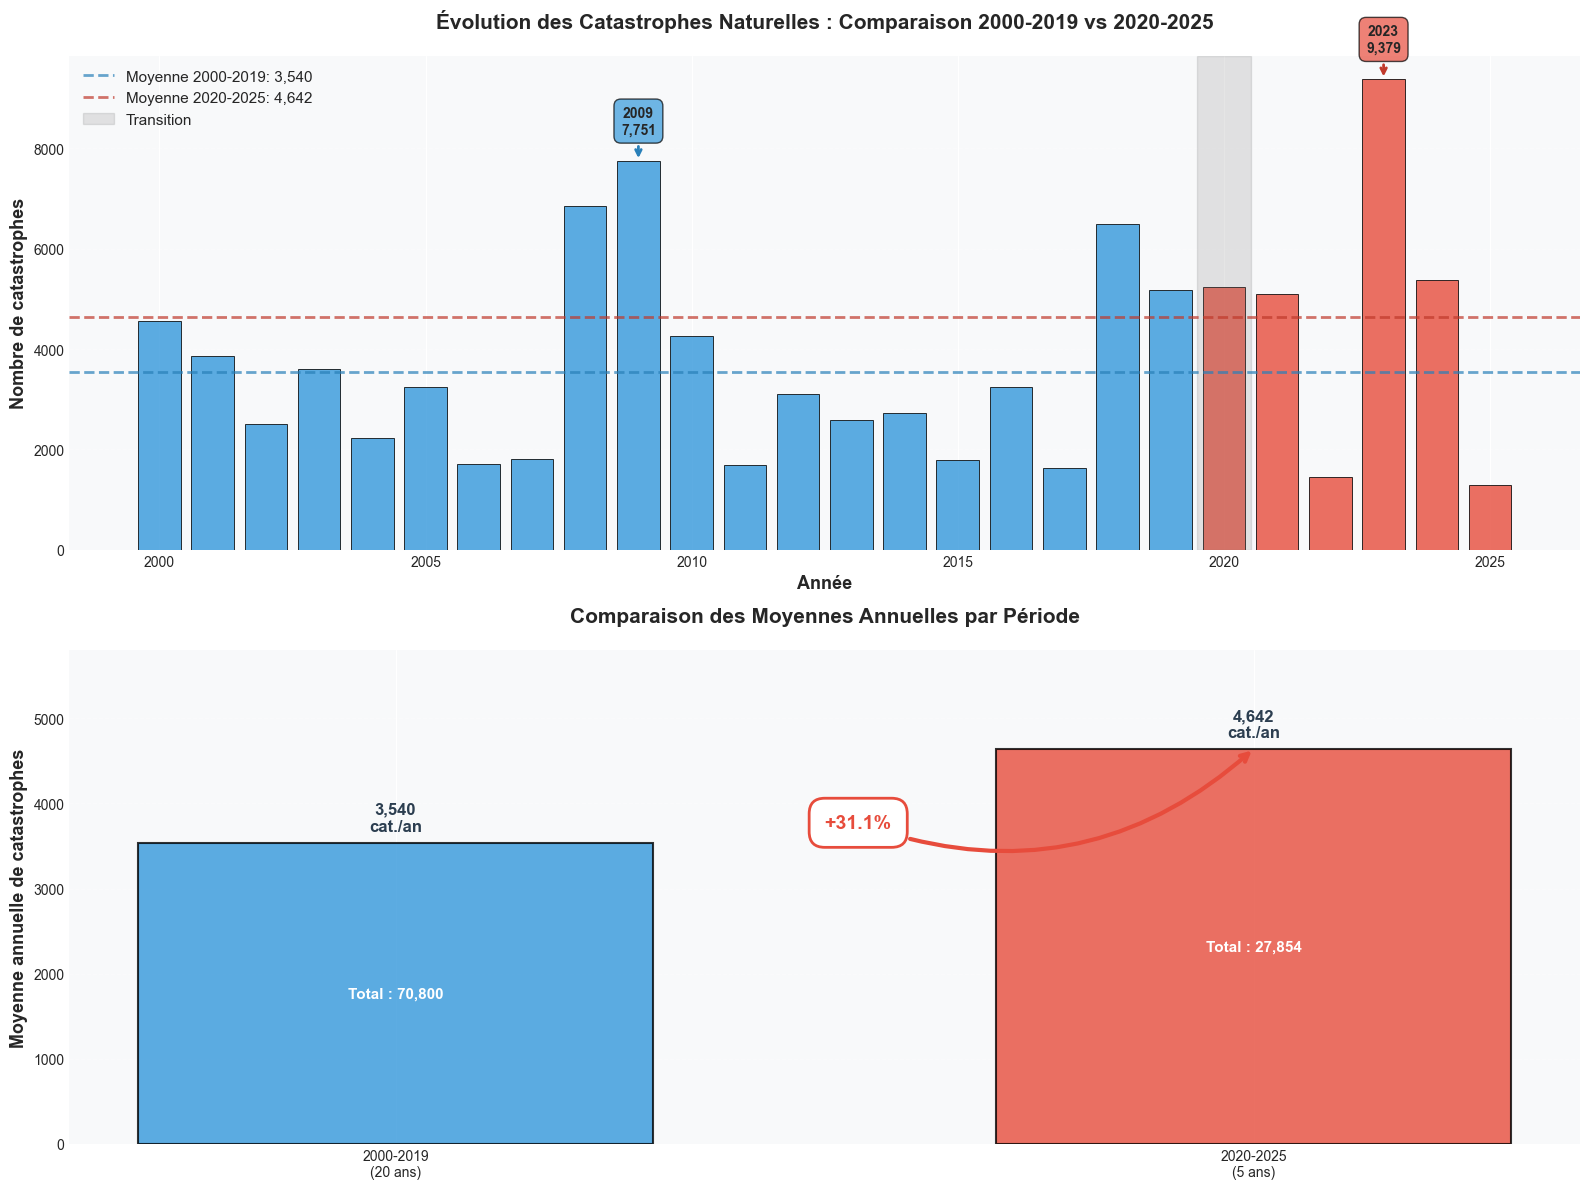


💡 INSIGHTS CLÉS :
   🔴 TENDANCE ALARMANTE : Augmentation de 31.1% de la moyenne annuelle
   📈 Les 5 dernières années (2020-2025) montrent un rythme 1.31x plus élevé
   ⚠️  Si cette tendance se maintient, on pourrait atteindre 92,847 catastrophes sur 20 ans
      (vs 70,800 catastrophes entre 2000-2019)

   📅 Répartition temporelle :
      • 2000-2019 : 70,800 catastrophes sur 20 ans (100%)
      • 2020-2025 : 27,854 catastrophes sur 5 ans (28.2% du total)

✅ Analyse comparative terminée


In [61]:
# ==========================================
# COMPARAISON TEMPORELLE : 20 PREMIÈRES ANNÉES vs 5 DERNIÈRES
# ==========================================

print("📊 COMPARAISON : 2000-2020 (20 ans) vs 2020-2025 (5 ans)\n")
print("=" * 80)

try:
    # Extraction des données année par année
    evolution_comparative = con.sql("""
        SELECT 
            YEAR(CAST(dat_pub_jo AS DATE)) as annee,
            COUNT(*) as nb_catastrophes,
            CASE 
                WHEN YEAR(CAST(dat_pub_jo AS DATE)) BETWEEN 2000 AND 2019 THEN '2000-2019'
                WHEN YEAR(CAST(dat_pub_jo AS DATE)) BETWEEN 2020 AND 2025 THEN '2020-2025'
            END as periode
        FROM catnat_gaspar
        WHERE YEAR(CAST(dat_pub_jo AS DATE)) BETWEEN 2000 AND 2025
        GROUP BY YEAR(CAST(dat_pub_jo AS DATE))
        ORDER BY annee
    """).df()
    
    # Séparer les deux périodes
    periode_2000_2019 = evolution_comparative[evolution_comparative['periode'] == '2000-2019']
    periode_2020_2025 = evolution_comparative[evolution_comparative['periode'] == '2020-2025']
    
    # Statistiques comparatives
    total_2000_2019 = periode_2000_2019['nb_catastrophes'].sum()
    total_2020_2025 = periode_2020_2025['nb_catastrophes'].sum()
    
    moyenne_2000_2019 = periode_2000_2019['nb_catastrophes'].mean()
    moyenne_2020_2025 = periode_2020_2025['nb_catastrophes'].mean()
    
    evolution_pct = ((moyenne_2020_2025 - moyenne_2000_2019) / moyenne_2000_2019) * 100
    
    print("\n📈 STATISTIQUES COMPARATIVES")
    print("=" * 80)
    print(f"\n🔹 PÉRIODE 2000-2019 (20 ans)")
    print(f"   • Total catastrophes        : {int(total_2000_2019):,}")
    print(f"   • Moyenne annuelle          : {moyenne_2000_2019:,.1f}")
    print(f"   • Année min                 : {int(periode_2000_2019['annee'].min())} ({int(periode_2000_2019['nb_catastrophes'].min()):,})")
    print(f"   • Année max                 : {int(periode_2000_2019.loc[periode_2000_2019['nb_catastrophes'].idxmax(), 'annee'])} ({int(periode_2000_2019['nb_catastrophes'].max()):,})")
    
    print(f"\n🔹 PÉRIODE 2020-2025 (5 ans)")
    print(f"   • Total catastrophes        : {int(total_2020_2025):,}")
    print(f"   • Moyenne annuelle          : {moyenne_2020_2025:,.1f}")
    print(f"   • Année min                 : {int(periode_2020_2025['annee'].min())} ({int(periode_2020_2025['nb_catastrophes'].min()):,})")
    print(f"   • Année max                 : {int(periode_2020_2025.loc[periode_2020_2025['nb_catastrophes'].idxmax(), 'annee'])} ({int(periode_2020_2025['nb_catastrophes'].max()):,})")
    
    print(f"\n⚖️  COMPARAISON")
    print("=" * 80)
    symbole = "📈" if evolution_pct > 0 else "📉"
    print(f"   {symbole} Évolution moyenne annuelle : {evolution_pct:+.1f}%")
    print(f"   📊 Ratio moyen : {moyenne_2020_2025 / moyenne_2000_2019:.2f}x")
    
    # Projection : si on maintenait le rythme 2020-2025 sur 20 ans
    projection_20ans = moyenne_2020_2025 * 20
    print(f"   🔮 Projection : si le rythme 2020-2025 se maintient sur 20 ans → {projection_20ans:,.0f} catastrophes (vs {total_2000_2019:,} en 2000-2019)")
    
    # Visualisation comparative avec barres superposées
    print("\n\n📊 VISUALISATION COMPARATIVE\n")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # GRAPHIQUE 1 : Évolution année par année avec distinction des périodes
    colors_1 = ['#3498db' if annee < 2020 else '#e74c3c' for annee in evolution_comparative['annee']]
    
    bars1 = ax1.bar(
        evolution_comparative['annee'], 
        evolution_comparative['nb_catastrophes'], 
        color=colors_1,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.8
    )
    
    # Lignes de moyenne par période
    ax1.axhline(y=moyenne_2000_2019, color='#2980b9', linestyle='--', linewidth=2, 
                label=f'Moyenne 2000-2019: {moyenne_2000_2019:,.0f}', alpha=0.7)
    ax1.axhline(y=moyenne_2020_2025, color='#c0392b', linestyle='--', linewidth=2, 
                label=f'Moyenne 2020-2025: {moyenne_2020_2025:,.0f}', alpha=0.7)
    
    # Zone de transition
    ax1.axvspan(2019.5, 2020.5, alpha=0.2, color='gray', label='Transition')
    
    ax1.set_xlabel('Année', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Nombre de catastrophes', fontsize=13, fontweight='bold')
    ax1.set_title(
        'Évolution des Catastrophes Naturelles : Comparaison 2000-2019 vs 2020-2025', 
        fontsize=15, 
        fontweight='bold', 
        pad=20
    )
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Annotations des années record
    annee_max_ancienne = periode_2000_2019.loc[periode_2000_2019['nb_catastrophes'].idxmax()]
    annee_max_recente = periode_2020_2025.loc[periode_2020_2025['nb_catastrophes'].idxmax()]
    
    ax1.annotate(
        f"{int(annee_max_ancienne['annee'])}\n{int(annee_max_ancienne['nb_catastrophes']):,}",
        xy=(annee_max_ancienne['annee'], annee_max_ancienne['nb_catastrophes']),
        xytext=(0, 20), textcoords='offset points',
        ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#3498db', alpha=0.7),
        arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2)
    )
    
    ax1.annotate(
        f"{int(annee_max_recente['annee'])}\n{int(annee_max_recente['nb_catastrophes']):,}",
        xy=(annee_max_recente['annee'], annee_max_recente['nb_catastrophes']),
        xytext=(0, 20), textcoords='offset points',
        ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#e74c3c', alpha=0.7),
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2)
    )
    
    # GRAPHIQUE 2 : Comparaison directe des moyennes
    periodes = ['2000-2019\n(20 ans)', '2020-2025\n(5 ans)']
    moyennes = [moyenne_2000_2019, moyenne_2020_2025]
    colors_2 = ['#3498db', '#e74c3c']
    
    bars2 = ax2.bar(periodes, moyennes, color=colors_2, edgecolor='black', linewidth=1.5, alpha=0.8, width=0.6)
    
    # Ajouter les valeurs sur les barres
    for i, (periode, moyenne) in enumerate(zip(periodes, moyennes)):
        ax2.text(i, moyenne + 100, f'{moyenne:,.0f}\ncat./an', 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2c3e50')
        
        # Ajouter le total de la période
        total = total_2000_2019 if i == 0 else total_2020_2025
        ax2.text(i, moyenne / 2, f'Total : {int(total):,}', 
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Flèche d'évolution
    ax2.annotate(
        f'{evolution_pct:+.1f}%',
        xy=(1, moyenne_2020_2025),
        xytext=(0.5, max(moyennes) * 0.8),
        fontsize=14, fontweight='bold', color='#e74c3c',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='#e74c3c', linewidth=2),
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3, connectionstyle='arc3,rad=0.3')
    )
    
    ax2.set_ylabel('Moyenne annuelle de catastrophes', fontsize=13, fontweight='bold')
    ax2.set_title(
        'Comparaison des Moyennes Annuelles par Période', 
        fontsize=15, 
        fontweight='bold', 
        pad=20
    )
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    ax2.set_ylim(0, max(moyennes) * 1.25)
    
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()
    
    # Insights finaux
    print("\n💡 INSIGHTS CLÉS :")
    print("=" * 80)
    if evolution_pct > 0:
        print(f"   🔴 TENDANCE ALARMANTE : Augmentation de {evolution_pct:.1f}% de la moyenne annuelle")
        print(f"   📈 Les 5 dernières années (2020-2025) montrent un rythme {moyenne_2020_2025 / moyenne_2000_2019:.2f}x plus élevé")
        print(f"   ⚠️  Si cette tendance se maintient, on pourrait atteindre {projection_20ans:,.0f} catastrophes sur 20 ans")
        print(f"      (vs {total_2000_2019:,} catastrophes entre 2000-2019)")
    else:
        print(f"   🟢 Diminution de {abs(evolution_pct):.1f}% de la moyenne annuelle")
        print(f"   📉 Les 5 dernières années montrent un ralentissement")
    
    # Analyse par répartition
    print(f"\n   📅 Répartition temporelle :")
    print(f"      • 2000-2019 : {total_2000_2019:,} catastrophes sur 20 ans ({total_2000_2019/total_2000_2019*100:.0f}%)")
    print(f"      • 2020-2025 : {total_2020_2025:,} catastrophes sur 5 ans ({total_2020_2025/(total_2000_2019+total_2020_2025)*100:.1f}% du total)")
    
    print("\n" + "=" * 80)
    print("✅ Analyse comparative terminée")
    
except Exception as e:
    print(f"⚠️  Erreur : {str(e)}")
    import traceback
    traceback.print_exc()

### 8.9 Analyse Régionale Comparative : 2000-2017 vs 2018-2025

🗺️  COMPARAISON RÉGIONALE : 2000-2017 (18 ans) vs 2018-2025 (7 ans)


📊 TABLEAU COMPARATIF PAR RÉGION
         Région           |    2000-2017 |    2018-2025 |    Évolution |       % Période
                          |     (18 ans) |      (7 ans) |       moy/an | ancienne/récente
--------------------------------------------------------------------------------
Nouvelle-Aquitaine        |        6,917 |        2,932 | 📈      9.0% |   70.2% /  29.8%
Auvergne-Rhône-Alpes      |        5,314 |        4,324 | 📈    109.2% |   55.1% /  44.9%
Occitanie                 |        5,238 |        2,844 | 📈     39.6% |   64.8% /  35.2%
Grand-Est                 |        2,821 |        5,193 | 📈    373.4% |   35.2% /  64.8%
Bourgogne-Franche-Comté   |        2,828 |        4,481 | 📈    307.4% |   38.7% /  61.3%
Hauts-de-France           |        3,883 |        2,928 | 📈     93.9% |   57.0% /  43.0%
Sud-Est PACA              |        3,627 |        2,293 | 📈     62.6% |   61.3% /  38.7%
Île-de-France  

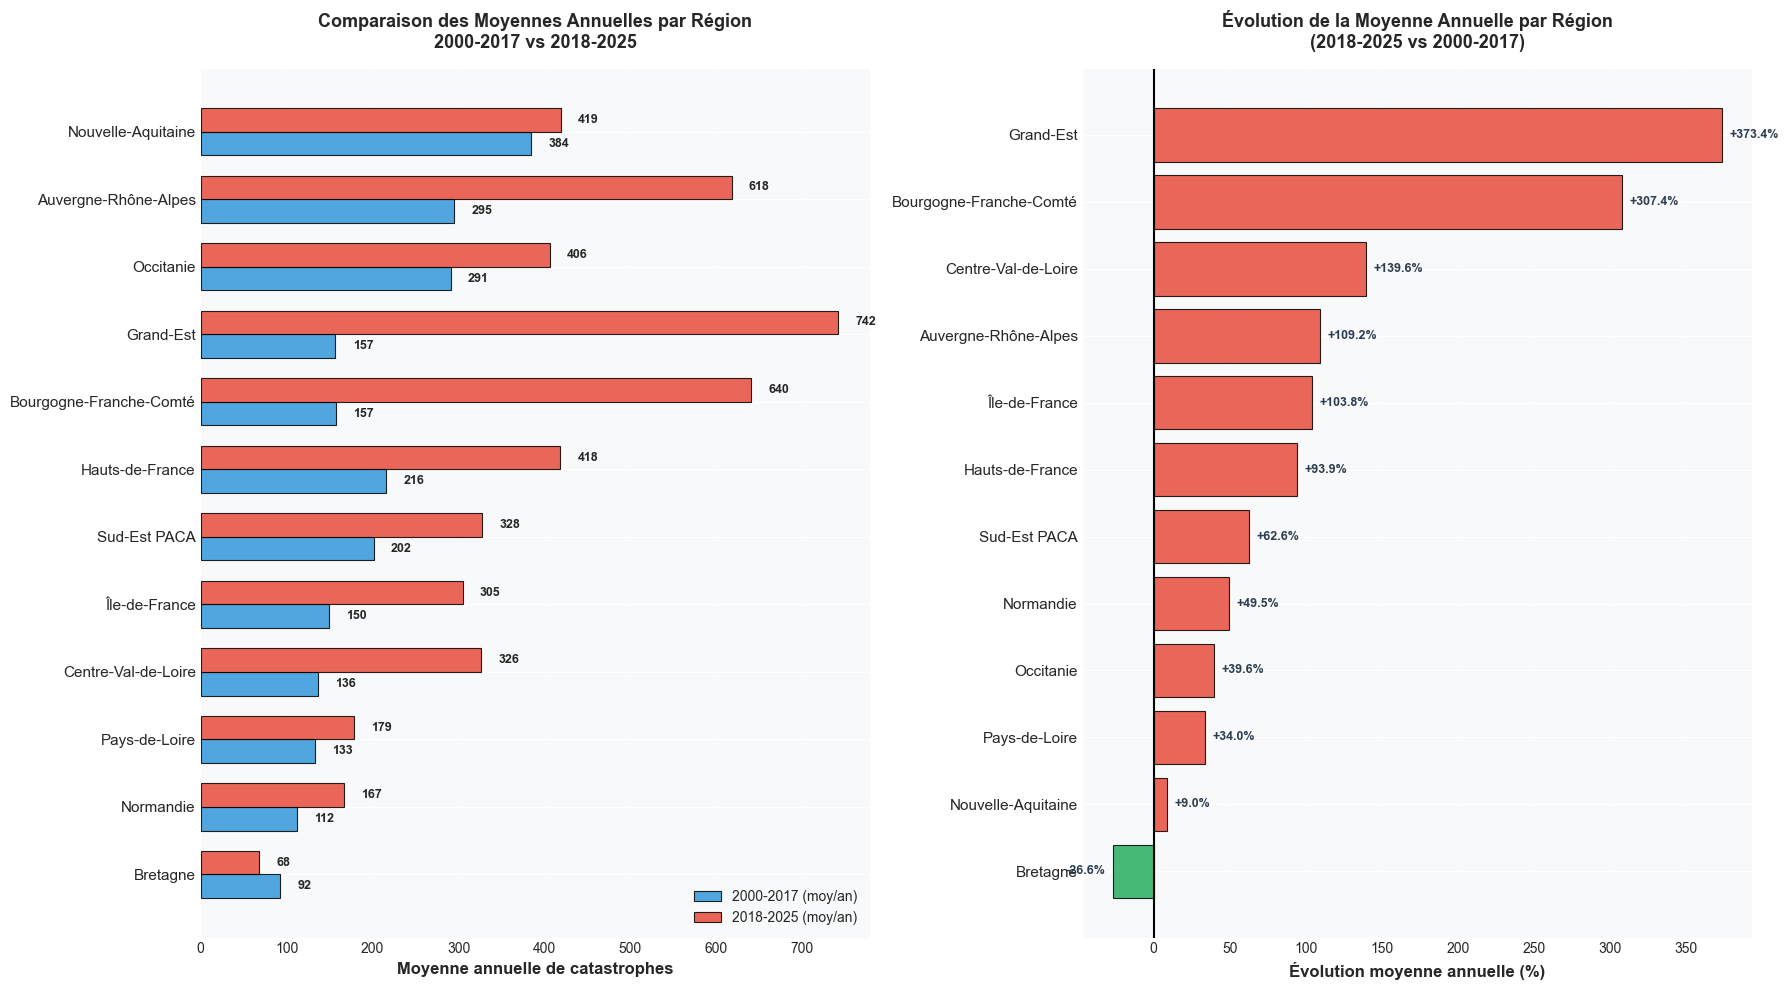



📊 RÉPARTITION EN POURCENTAGE DU TOTAL NATIONAL

         Région           |  % 2000-2017 |  % 2018-2025 |    Évolution
--------------------------------------------------------------------------------
Grand-Est                 |        4.77% |       13.14% | ↗️     +8.37%
Bourgogne-Franche-Comté   |        4.78% |       11.34% | ↗️     +6.56%
Auvergne-Rhône-Alpes      |        8.99% |       10.94% | ↗️     +1.95%
Nouvelle-Aquitaine        |       11.70% |        7.42% | ↘️     -4.28%
Hauts-de-France           |        6.57% |        7.41% | ↗️     +0.84%
Occitanie                 |        8.86% |        7.20% | ↘️     -1.66%
Sud-Est PACA              |        6.13% |        5.80% | ↘️     -0.33%
Centre-Val-de-Loire       |        4.14% |        5.77% | ↗️     +1.63%
Île-de-France             |        4.55% |        5.40% | ↗️     +0.85%
Pays-de-Loire             |        4.06% |        3.16% | ↘️     -0.90%
Normandie                 |        3.39% |        2.95% | ↘️     -0.44%
Bretag

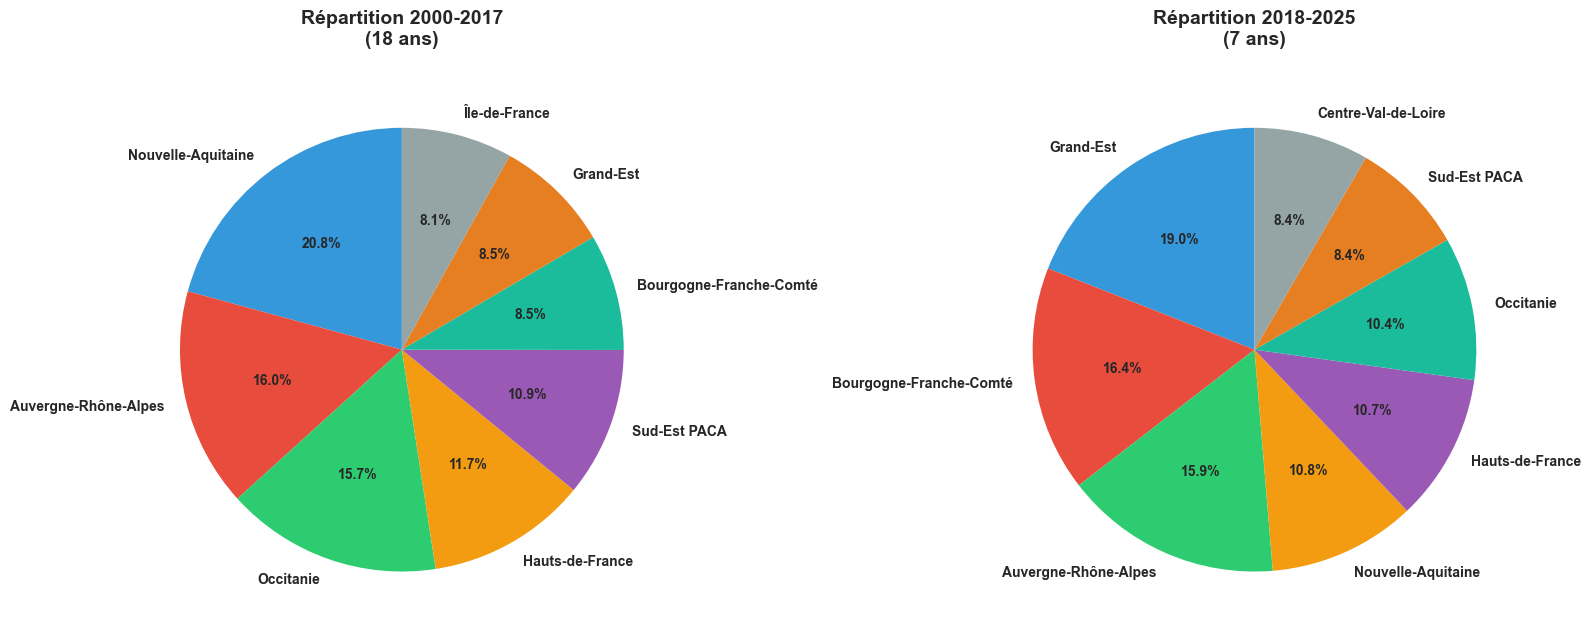


💡 INSIGHTS CLÉS PAR RÉGION :

   🔴 Plus forte hausse : Grand-Est (+373.4%)
   🟢 Plus forte baisse : Bretagne (-26.6%)

   📊 Régions gagnant en part nationale (>0.5%) :
      • Grand-Est                      : +8.37% (4.77% → 13.14%)
      • Bourgogne-Franche-Comté        : +6.56% (4.78% → 11.34%)
      • Auvergne-Rhône-Alpes           : +1.95% (8.99% → 10.94%)
      • Hauts-de-France                : +0.84% (6.57% → 7.41%)
      • Centre-Val-de-Loire            : +1.63% (4.14% → 5.77%)
      • Île-de-France                  : +0.85% (4.55% → 5.40%)

✅ Analyse régionale comparative terminée


In [62]:
# ==========================================
# COMPARAISON RÉGIONALE : 18 ANNÉES vs 7 DERNIÈRES
# ==========================================

print("🗺️  COMPARAISON RÉGIONALE : 2000-2017 (18 ans) vs 2018-2025 (7 ans)\n")
print("=" * 80)

try:
    # Extraction des données par région et période
    comparaison_regions = con.sql("""
        SELECT 
            CASE 
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('06', '13', '83', '84') THEN 'Sud-Est PACA'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('33', '40', '64', '47') THEN 'Nouvelle-Aquitaine'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('11', '30', '34', '48', '66') THEN 'Occitanie'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('69', '01', '42', '73', '74', '38', '26', '07', '03', '15', '43', '63') THEN 'Auvergne-Rhône-Alpes'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('67', '68', '54', '57', '88', '08', '10', '51', '52') THEN 'Grand-Est'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('44', '49', '53', '72', '85') THEN 'Pays-de-Loire'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('75', '91', '92', '93', '94', '95', '77', '78') THEN 'Île-de-France'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('22', '29', '35', '56') THEN 'Bretagne'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('14', '27', '50', '61', '76') THEN 'Normandie'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('02', '59', '60', '62', '80') THEN 'Hauts-de-France'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('21', '25', '39', '58', '70', '71', '89', '90') THEN 'Bourgogne-Franche-Comté'
                WHEN SUBSTRING(cod_commune, 1, 2) IN ('18', '28', '36', '37', '41', '45') THEN 'Centre-Val-de-Loire'
                ELSE 'Autres'
            END as region,
            CASE 
                WHEN YEAR(CAST(dat_pub_jo AS DATE)) BETWEEN 2000 AND 2017 THEN '2000-2017'
                WHEN YEAR(CAST(dat_pub_jo AS DATE)) BETWEEN 2018 AND 2025 THEN '2018-2025'
            END as periode,
            COUNT(*) as nb_catastrophes
        FROM catnat_gaspar
        WHERE YEAR(CAST(dat_pub_jo AS DATE)) BETWEEN 2000 AND 2025
        GROUP BY region, periode
        ORDER BY region, periode
    """).df()
    
    # Créer un pivot pour faciliter la comparaison
    pivot_regions = comparaison_regions.pivot(index='region', columns='periode', values='nb_catastrophes').fillna(0)
    pivot_regions['evolution_pct'] = ((pivot_regions['2018-2025'] / 7) - (pivot_regions['2000-2017'] / 18)) / (pivot_regions['2000-2017'] / 18) * 100
    pivot_regions['moyenne_2000_2017'] = pivot_regions['2000-2017'] / 18
    pivot_regions['moyenne_2018_2025'] = pivot_regions['2018-2025'] / 7
    pivot_regions['total'] = pivot_regions['2000-2017'] + pivot_regions['2018-2025']
    pivot_regions['pct_2000_2017'] = (pivot_regions['2000-2017'] / pivot_regions['total'] * 100).round(1)
    pivot_regions['pct_2018_2025'] = (pivot_regions['2018-2025'] / pivot_regions['total'] * 100).round(1)
    
    # Trier par total décroissant
    pivot_regions = pivot_regions.sort_values('total', ascending=False)
    
    # Afficher le tableau comparatif
    print("\n📊 TABLEAU COMPARATIF PAR RÉGION")
    print("=" * 80)
    print(f"{'Région':^25} | {'2000-2017':>12} | {'2018-2025':>12} | {'Évolution':>12} | {'% Période':>15}")
    print(f"{'':^25} | {'(18 ans)':>12} | {'(7 ans)':>12} | {'moy/an':>12} | {'ancienne/récente':>15}")
    print("-" * 80)
    
    for region, row in pivot_regions.iterrows():
        if region != 'Autres':
            symbole = "📈" if row['evolution_pct'] > 0 else "📉"
            print(f"{region:25} | {int(row['2000-2017']):>12,} | {int(row['2018-2025']):>12,} | {symbole} {row['evolution_pct']:>8.1f}% | {row['pct_2000_2017']:>6.1f}% / {row['pct_2018_2025']:>5.1f}%")
    
    print("=" * 80)
    
    # Calculer les totaux nationaux
    total_2000_2017 = pivot_regions['2000-2017'].sum()
    total_2018_2025 = pivot_regions['2018-2025'].sum()
    
    print(f"\n{'TOTAL NATIONAL':25} | {int(total_2000_2017):>12,} | {int(total_2018_2025):>12,}")
    print(f"{'Moyenne annuelle':25} | {total_2000_2017/18:>12,.0f} | {total_2018_2025/7:>12,.0f}")
    
    # Identifier les régions avec plus forte évolution
    top_hausse = pivot_regions.nlargest(3, 'evolution_pct')
    top_baisse = pivot_regions.nsmallest(3, 'evolution_pct')
    
    print("\n\n🔝 TOP 3 RÉGIONS EN FORTE HAUSSE")
    print("=" * 80)
    for region, row in top_hausse.iterrows():
        if region != 'Autres':
            print(f"   📈 {region:30} : +{row['evolution_pct']:.1f}% ({row['moyenne_2000_2017']:.0f} → {row['moyenne_2018_2025']:.0f} cat./an)")
    
    if top_baisse['evolution_pct'].iloc[0] < 0:
        print("\n\n📉 TOP 3 RÉGIONS EN BAISSE")
        print("=" * 80)
        for region, row in top_baisse.iterrows():
            if region != 'Autres' and row['evolution_pct'] < 0:
                print(f"   📉 {region:30} : {row['evolution_pct']:.1f}% ({row['moyenne_2000_2017']:.0f} → {row['moyenne_2018_2025']:.0f} cat./an)")
    
    # Visualisation comparative par région
    print("\n\n📊 VISUALISATION COMPARATIVE PAR RÉGION\n")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    
    # Filtrer "Autres" et trier
    regions_principales = pivot_regions[pivot_regions.index != 'Autres'].sort_values('total', ascending=True)
    
    # GRAPHIQUE 1 : Barres horizontales groupées
    y_pos = range(len(regions_principales))
    width = 0.35
    
    bars1 = ax1.barh(
        [y - width/2 for y in y_pos],
        regions_principales['moyenne_2000_2017'],
        width,
        label='2000-2017 (moy/an)',
        color='#3498db',
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    bars2 = ax1.barh(
        [y + width/2 for y in y_pos],
        regions_principales['moyenne_2018_2025'],
        width,
        label='2018-2025 (moy/an)',
        color='#e74c3c',
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(regions_principales.index, fontsize=11)
    ax1.set_xlabel('Moyenne annuelle de catastrophes', fontsize=12, fontweight='bold')
    ax1.set_title('Comparaison des Moyennes Annuelles par Région\n2000-2017 vs 2018-2025', 
                  fontsize=13, fontweight='bold', pad=15)
    ax1.legend(loc='lower right', fontsize=10, framealpha=0.95)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.set_facecolor('#f8f9fa')
    
    # Ajouter les valeurs sur les barres
    for i, (idx, row) in enumerate(regions_principales.iterrows()):
        ax1.text(row['moyenne_2000_2017'] + 20, i - width/2, f"{row['moyenne_2000_2017']:.0f}", 
                va='center', fontsize=9, fontweight='bold')
        ax1.text(row['moyenne_2018_2025'] + 20, i + width/2, f"{row['moyenne_2018_2025']:.0f}", 
                va='center', fontsize=9, fontweight='bold')
    
    # GRAPHIQUE 2 : Pourcentage d'évolution par région
    regions_triees = regions_principales.sort_values('evolution_pct', ascending=True)
    colors_evolution = ['#27ae60' if x < 0 else '#e74c3c' for x in regions_triees['evolution_pct']]
    
    bars3 = ax2.barh(
        range(len(regions_triees)),
        regions_triees['evolution_pct'],
        color=colors_evolution,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    ax2.set_yticks(range(len(regions_triees)))
    ax2.set_yticklabels(regions_triees.index, fontsize=11)
    ax2.set_xlabel('Évolution moyenne annuelle (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Évolution de la Moyenne Annuelle par Région\n(2018-2025 vs 2000-2017)', 
                  fontsize=13, fontweight='bold', pad=15)
    ax2.axvline(x=0, color='black', linewidth=1.5, linestyle='-')
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    ax2.set_facecolor('#f8f9fa')
    
    # Ajouter les valeurs sur les barres
    for i, (idx, row) in enumerate(regions_triees.iterrows()):
        value = row['evolution_pct']
        x_pos = value + (5 if value > 0 else -5)
        ha = 'left' if value > 0 else 'right'
        ax2.text(x_pos, i, f"{value:+.1f}%", 
                va='center', ha=ha, fontsize=9, fontweight='bold', color='#2c3e50')
    
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()
    
    # Analyse des répartitions en pourcentage
    print("\n\n📊 RÉPARTITION EN POURCENTAGE DU TOTAL NATIONAL")
    print("=" * 80)
    
    # Calculer les pourcentages nationaux pour chaque période
    regions_pct = pivot_regions[pivot_regions.index != 'Autres'].copy()
    regions_pct['pct_national_2000_2017'] = (regions_pct['2000-2017'] / total_2000_2017 * 100).round(2)
    regions_pct['pct_national_2018_2025'] = (regions_pct['2018-2025'] / total_2018_2025 * 100).round(2)
    regions_pct['evolution_part_nationale'] = (regions_pct['pct_national_2018_2025'] - regions_pct['pct_national_2000_2017']).round(2)
    
    regions_pct = regions_pct.sort_values('pct_national_2018_2025', ascending=False)
    
    print(f"\n{'Région':^25} | {'% 2000-2017':>12} | {'% 2018-2025':>12} | {'Évolution':>12}")
    print("-" * 80)
    
    for region, row in regions_pct.iterrows():
        symbole = "↗️" if row['evolution_part_nationale'] > 0 else "↘️" if row['evolution_part_nationale'] < 0 else "→"
        print(f"{region:25} | {row['pct_national_2000_2017']:>11.2f}% | {row['pct_national_2018_2025']:>11.2f}% | {symbole} {row['evolution_part_nationale']:>+9.2f}%")
    
    print("=" * 80)
    
    # Graphique camembert comparatif
    print("\n\n🥧 VISUALISATION DES PARTS NATIONALES\n")
    
    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Top 8 régions pour la lisibilité
    top8_2000_2017 = regions_pct.nlargest(8, 'pct_national_2000_2017')
    top8_2018_2025 = regions_pct.nlargest(8, 'pct_national_2018_2025')
    
    # Camembert 2000-2017
    colors_pie = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
    
    wedges1, texts1, autotexts1 = ax3.pie(
        top8_2000_2017['pct_national_2000_2017'],
        labels=top8_2000_2017.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    ax3.set_title('Répartition 2000-2017\n(18 ans)', fontsize=14, fontweight='bold', pad=20)
    
    # Camembert 2018-2025
    wedges2, texts2, autotexts2 = ax4.pie(
        top8_2018_2025['pct_national_2018_2025'],
        labels=top8_2018_2025.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    ax4.set_title('Répartition 2018-2025\n(7 ans)', fontsize=14, fontweight='bold', pad=20)
    
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()
    
    # Insights finaux
    print("\n💡 INSIGHTS CLÉS PAR RÉGION :")
    print("=" * 80)
    
    hausse_max = regions_principales['evolution_pct'].max()
    region_hausse_max = regions_principales['evolution_pct'].idxmax()
    
    baisse_min = regions_principales['evolution_pct'].min()
    region_baisse_min = regions_principales['evolution_pct'].idxmin()
    
    print(f"\n   🔴 Plus forte hausse : {region_hausse_max} (+{hausse_max:.1f}%)")
    if baisse_min < 0:
        print(f"   🟢 Plus forte baisse : {region_baisse_min} ({baisse_min:.1f}%)")
    
    # Régions avec part nationale en hausse
    regions_hausse_pct = regions_pct[regions_pct['evolution_part_nationale'] > 0.5]
    if len(regions_hausse_pct) > 0:
        print(f"\n   📊 Régions gagnant en part nationale (>0.5%) :")
        for region, row in regions_hausse_pct.iterrows():
            print(f"      • {region:30} : +{row['evolution_part_nationale']:.2f}% ({row['pct_national_2000_2017']:.2f}% → {row['pct_national_2018_2025']:.2f}%)")
    
    print("\n" + "=" * 80)
    print("✅ Analyse régionale comparative terminée")
    
except Exception as e:
    print(f"⚠️  Erreur : {str(e)}")
    import traceback
    traceback.print_exc()

---
## 9. Nettoyage

In [14]:
# ==========================================
# FERMETURE DE LA CONNEXION
# ==========================================

con.close()
print("✅ Connexion DuckDB fermée")
print("📁 Analyse terminée avec succès !")

✅ Connexion DuckDB fermée
📁 Analyse terminée avec succès !


---

## 📚 Références

- **DuckDB** : https://duckdb.org/docs/
- **Pandas** : https://pandas.pydata.org/docs/
- **GASPAR** : https://www.georisques.gouv.fr/
- **Data For Good** : https://dataforgood.fr/

---

**Version** : 2.0 (Finalisée)  
**Dernière modification** : 2026-02-23